### 코드 잘 돌아가는지 확인하는 임시 ipynb 파일

In [1]:
import sys
import os
import glob 

# 현재 작업 디렉토리 기준으로 두 단계 상위 디렉토리(루트)를 경로에 추가
sys.path.append(os.path.abspath(os.path.join('..', '..')))


from funs import utils
from funs import  download

from nptdms import TdmsFile
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from tqdm import tqdm 
import scipy.stats as stats

from natsort import natsorted

from scipy.signal import butter, filtfilt, hilbert

In [2]:
config = utils.load_yaml("./config.yaml")

In [3]:
# import os, glob
# import pandas as pd
# from natsort import natsorted

# DATA_ROOT = config['root_dataset']

# def read_csv_robust(path):
#     """인코딩을 순서대로 시도"""
#     for enc in ['utf-8', 'cp949', 'euc-kr', 'latin-1']:
#         try:
#             return pd.read_csv(path, encoding=enc), enc
#         except UnicodeDecodeError:
#             continue
#     raise ValueError(f"읽기 실패: {path}")

# summary = []
# for i in range(1, 5):
#     vib_dir = os.path.join(DATA_ROOT, f"Train{i}_Vibration")
#     op_path = os.path.join(DATA_ROOT, f"Train{i}_Operation.csv")

#     # 1) TDMS 파일 목록 — natural sort
#     tdms_files = natsorted(glob.glob(os.path.join(vib_dir, "*.tdms")))
#     first_names = [os.path.basename(f) for f in tdms_files[:3]]
#     last_names  = [os.path.basename(f) for f in tdms_files[-3:]]

#     # 2) Operation.csv (인코딩 자동)
#     op, used_enc = read_csv_robust(op_path)

#     print(f"\n=== Train{i} ===")
#     print(f"  TDMS 파일 수: {len(tdms_files)}")
#     print(f"  첫 3개 파일명: {first_names}")
#     print(f"  마지막 3개 파일명: {last_names}")
#     print(f"  Operation encoding: {used_enc}")
#     print(f"  Operation shape: {op.shape}")
#     print(f"  Operation 컬럼: {list(op.columns)}")
#     print(f"  Operation head:")
#     print(op.head(2))
#     print(f"  Operation tail:")
#     print(op.tail(2))

#     summary.append({
#         'train': f'Train{i}',
#         'n_tdms': len(tdms_files),
#         'n_op_rows': len(op),
#         'encoding': used_enc,
#     })

# print("\n=== 요약 ===")
# print(pd.DataFrame(summary))

In [4]:
download.download_dataset(config['root_dataset'])

이미 데이터셋이 존재합니다. 다운로드를 건너뜁니다.


In [5]:
DATA_ROOT = config['root_dataset']
FILE_INTERVAL_SEC = 600  # 10분 주기로 파일 취득

def read_operation(path):
    df = pd.read_csv(path, encoding='cp949')
    # 컬럼명 공백 제거
    df.columns = df.columns.str.strip()
    # 빈 컬럼 제거 (Train2의 '' 컬럼)
    df = df.loc[:, df.columns != '']
    # 통일된 컬럼명
    df = df.rename(columns={
        'Time[sec]': 'time_sec',
        'Torque[Nm]': 'torque',
        'Motor speed[rpm]': 'rpm',
        'TC SP Front[℃]': 'temp_front',
        'TC SP Rear[℃]': 'temp_rear',
    })
    return df

def find_eol(op_df, torque_thr=-20.0, temp_thr=200.0):
    """토크 ≤ -20 또는 온도 ≥ 200 을 최초로 만족하는 시각(초)"""
    cond = (op_df['torque'] <= torque_thr) | \
           (op_df['temp_front'] >= temp_thr) | \
           (op_df['temp_rear']  >= temp_thr)
    if cond.any():
        return op_df.loc[cond, 'time_sec'].iloc[0]
    # 못 찾으면 마지막 시점 반환 (안전장치)
    return op_df['time_sec'].iloc[-1]

def extract_vib_features(tdms_path):
    """하나의 TDMS 파일에서 4채널 time-domain feature 추출"""
    df = TdmsFile.read(tdms_path).as_dataframe()
    feat = {}
    for ch in ['CH1', 'CH2', 'CH3', 'CH4']:
        col = [c for c in df.columns if ch in str(c)][0]
        x = df[col].dropna().values.astype(np.float32)
        feat[f'{ch}_RMS']      = float(np.sqrt(np.mean(x**2)))
        feat[f'{ch}_Kurt']     = float(stats.kurtosis(x, fisher=False))
        feat[f'{ch}_P2P']      = float(x.max() - x.min())
        feat[f'{ch}_CrestF']   = float(np.max(np.abs(x)) / (np.sqrt(np.mean(x**2)) + 1e-12))
        feat[f'{ch}_Std']      = float(np.std(x))
    return feat

all_runs = []
eol_info = []

for i in range(1, 5):
    run_id = f'Train{i}'
    vib_dir = os.path.join(DATA_ROOT, f'{run_id}_Vibration')
    op_path = os.path.join(DATA_ROOT, f'{run_id}_Operation.csv')

    op = read_operation(op_path)
    eol_time = find_eol(op)
    eol_info.append({'run': run_id, 'eol_sec': eol_time, 'eol_hour': eol_time/3600})

    tdms_files = natsorted(glob.glob(os.path.join(vib_dir, '*.tdms')))

    rows = []
    for idx, fp in enumerate(tqdm(tdms_files, desc=run_id)):
        t_start = idx * FILE_INTERVAL_SEC  # 파일 시작 시각(초)

        # 해당 시각의 Operation 신호 값 (가장 가까운 행)
        nearest_idx = (op['time_sec'] - t_start).abs().idxmin()
        op_row = op.loc[nearest_idx]

        row = {
            'run': run_id,
            'file_idx': idx,
            'time_sec': t_start,
            'rul_sec': max(eol_time - t_start, 0),  # RUL 라벨
            'torque': op_row['torque'],
            'rpm':    op_row['rpm'],
            'temp_front': op_row['temp_front'],
            'temp_rear':  op_row['temp_rear'],
        }
        row.update(extract_vib_features(fp))
        rows.append(row)

    all_runs.append(pd.DataFrame(rows))

feature_df = pd.concat(all_runs, ignore_index=True)

print("\n=== EOL 요약 ===")
print(pd.DataFrame(eol_info))
print("\n=== feature_df shape:", feature_df.shape)
print(feature_df.head(3))

# 저장해두면 이후 모델링에서 재활용 편함
feature_df.to_csv('feature_df.csv', index=False)



Train4: 100%|██████████| 137/137 [00:20<00:00,  6.61it/s]


=== EOL 요약 ===
      run  eol_sec   eol_hour
0  Train1    75251  20.903056
1  Train2    67979  18.883056
2  Train3    53225  14.784722
3  Train4    82613  22.948056

=== feature_df shape: (466, 28)
      run  file_idx  time_sec  rul_sec  torque    rpm  temp_front  temp_rear  \
0  Train1         0         0    75251  -4.531  498.0      10.279     10.389   
1  Train1         1       600    74651  -2.997  740.0      14.166     14.190   
2  Train1         2      1200    74051  -2.774  740.0      16.962     16.657   

    CH1_RMS  CH1_Kurt  ...   CH3_RMS  CH3_Kurt   CH3_P2P  CH3_CrestF  \
0  0.150527  4.113484  ...  0.125165  4.096688  1.687431    7.253616   
1  0.150666  4.133367  ...  0.126157  4.091687  1.639652    6.592578   
2  0.148393  4.142585  ...  0.125212  4.083502  1.613235    6.835787   

    CH3_Std   CH4_RMS  CH4_Kurt   CH4_P2P  CH4_CrestF   CH4_Std  
0  0.125141  0.170665  3.831248  2.040482    5.980260  0.170665  
1  0.126146  0.172179  3.814291  2.054119    6.058412  0.17

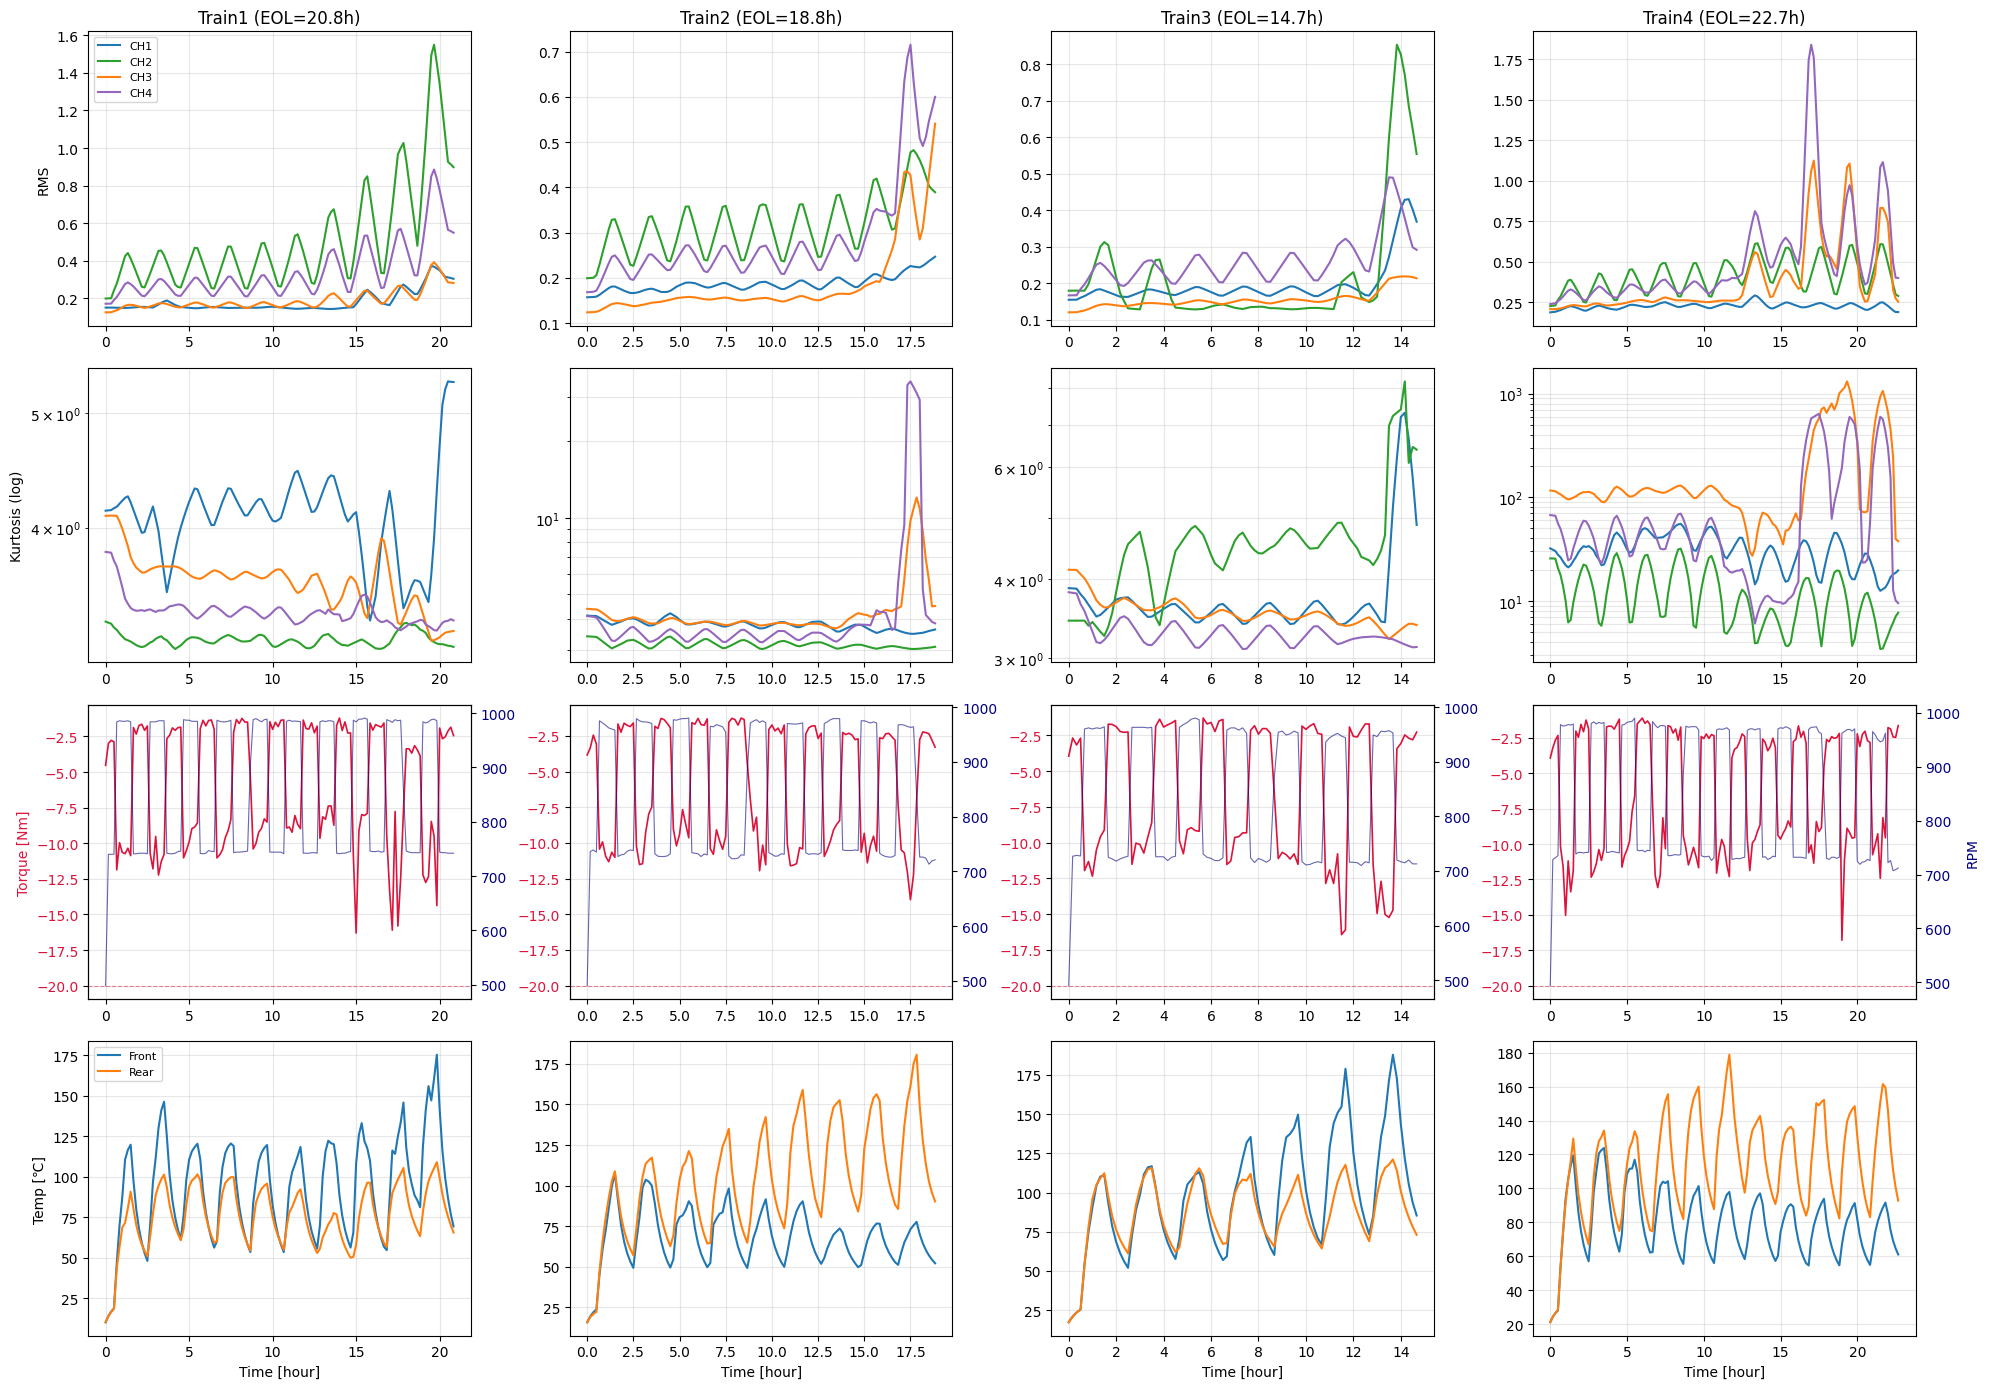

In [6]:
runs = ['Train1', 'Train2', 'Train3', 'Train4']
colors = {'CH1': 'tab:blue', 'CH2': 'tab:green', 'CH3': 'tab:orange', 'CH4': 'tab:purple'}

# Run별 smoothing
def smooth(s, w=5):
    return s.rolling(w, center=True, min_periods=1).median().rolling(w, min_periods=1).mean()

fig, axes = plt.subplots(4, 4, figsize=(20, 14), sharex=False)
# 열: Train1~4 / 행: RMS, Kurtosis, Torque+RPM, Temp

for col, run in enumerate(runs):
    sub = feature_df[feature_df['run'] == run].reset_index(drop=True)
    t_hr = sub['time_sec'] / 3600  # 시간 단위

    # --- 1행: RMS (4채널) ---
    ax = axes[0, col]
    for ch in ['CH1', 'CH2', 'CH3', 'CH4']:
        ax.plot(t_hr, smooth(sub[f'{ch}_RMS']), label=ch, color=colors[ch], lw=1.5)
    ax.set_title(f'{run} (EOL={sub["time_sec"].iloc[-1]/3600:.1f}h)')
    ax.set_ylabel('RMS' if col == 0 else '')
    ax.grid(alpha=0.3)
    if col == 0: ax.legend(fontsize=8, loc='upper left')

    # --- 2행: Kurtosis (4채널, log scale) ---
    ax = axes[1, col]
    for ch in ['CH1', 'CH2', 'CH3', 'CH4']:
        ax.plot(t_hr, smooth(sub[f'{ch}_Kurt']), label=ch, color=colors[ch], lw=1.5)
    ax.set_yscale('log')
    ax.set_ylabel('Kurtosis (log)' if col == 0 else '')
    ax.grid(alpha=0.3, which='both')

    # --- 3행: Torque & RPM ---
    ax = axes[2, col]
    ax.plot(t_hr, sub['torque'], color='crimson', lw=1.2, label='Torque')
    ax.set_ylabel('Torque [Nm]' if col == 0 else '', color='crimson')
    ax.tick_params(axis='y', labelcolor='crimson')
    ax.axhline(-20, color='crimson', ls='--', alpha=0.5, lw=0.8)
    ax.grid(alpha=0.3)
    ax2 = ax.twinx()
    ax2.plot(t_hr, sub['rpm'], color='navy', lw=0.8, alpha=0.6, label='RPM')
    ax2.set_ylabel('RPM' if col == 3 else '', color='navy')
    ax2.tick_params(axis='y', labelcolor='navy')

    # --- 4행: Temperature ---
    ax = axes[3, col]
    ax.plot(t_hr, sub['temp_front'], color='tab:blue',   lw=1.5, label='Front')
    ax.plot(t_hr, sub['temp_rear'],  color='tab:orange', lw=1.5, label='Rear')
    ax.set_ylabel('Temp [℃]' if col == 0 else '')
    ax.set_xlabel('Time [hour]')
    ax.grid(alpha=0.3)
    if col == 0: ax.legend(fontsize=8, loc='upper left')

plt.tight_layout()
plt.show()

In [7]:

DATA_ROOT = config['root_dataset']
FS = 25600              # 진동 샘플링 주파수 [Hz]
FILE_INTERVAL_SEC = 600 # 파일 간 경과 시간 [초]

# 1000rpm 기준 특성 주파수
BEARING_FREQS_1000RPM = {'BPFI': 140, 'BPFO': 93, 'BSF': 78}
TOL = 0.05  # 피크 탐색 허용 오차 ±5%


# ---------- 유틸 ----------
def read_operation(path):
    df = pd.read_csv(path, encoding='cp949')
    df.columns = df.columns.str.strip()
    df = df.loc[:, df.columns != '']
    return df.rename(columns={
        'Time[sec]': 'time_sec', 'Torque[Nm]': 'torque',
        'Motor speed[rpm]': 'rpm',
        'TC SP Front[℃]': 'temp_front', 'TC SP Rear[℃]': 'temp_rear',
    })

def find_eol(op, torque_thr=-20.0, temp_thr=200.0):
    cond = ((op['torque'] <= torque_thr) |
            (op['temp_front'] >= temp_thr) |
            (op['temp_rear']  >= temp_thr))
    return op.loc[cond, 'time_sec'].iloc[0] if cond.any() else op['time_sec'].iloc[-1]


# ---------- 시간 영역 feature ----------
def time_features(x):
    rms = float(np.sqrt(np.mean(x**2)))
    return {
        'RMS':  rms,
        'Kurt': float(stats.kurtosis(x, fisher=False)),
        'P2P':  float(x.max() - x.min()),
        'CrestF': float(np.max(np.abs(x)) / (rms + 1e-12)),
        'Std':  float(np.std(x)),
    }


# ---------- Envelope spectrum feature ----------
def envelope_spectrum(x, fs=FS, hp_cut=1000.0):
    """
    1) 고주파 대역통과(1kHz~Nyquist) → 결함 공진대 추출
    2) Hilbert envelope → 충격 포락선
    3) FFT → 포락선 스펙트럼 (주파수, 크기)
    """
    nyq = fs / 2
    # 고역통과 필터: 1kHz 이상 (기계 회전 기본주파수 제거)
    b, a = butter(4, hp_cut/nyq, btype='high')
    x_bp = filtfilt(b, a, x)
    # Hilbert 포락선
    env = np.abs(hilbert(x_bp))
    env = env - env.mean()  # DC 제거
    # FFT
    N = len(env)
    freqs = np.fft.rfftfreq(N, d=1/fs)
    spec  = np.abs(np.fft.rfft(env)) / N
    return freqs, spec

def band_energy(freqs, spec, f_center, tol=TOL):
    """f_center 주변 ±tol 대역의 피크 에너지(최댓값) 반환"""
    lo, hi = f_center*(1-tol), f_center*(1+tol)
    mask = (freqs >= lo) & (freqs <= hi)
    return float(spec[mask].max()) if mask.any() else 0.0

def bearing_fault_features(x, rpm):
    """현재 RPM에 맞춰 스케일한 BPFI/BPFO/BSF 에너지 추출"""
    freqs, spec = envelope_spectrum(x)
    scale = rpm / 1000.0
    feats = {}
    for name, f_ref in BEARING_FREQS_1000RPM.items():
        f_actual = f_ref * scale
        feats[name] = band_energy(freqs, spec, f_actual)
    return feats


# ---------- 파일 하나 처리 ----------
def extract_all_features(tdms_path, rpm):
    df = TdmsFile.read(tdms_path).as_dataframe()
    out = {}
    for ch in ['CH1', 'CH2', 'CH3', 'CH4']:
        col = [c for c in df.columns if ch in str(c)][0]
        x = df[col].dropna().values.astype(np.float32)

        # 시간 영역
        for k, v in time_features(x).items():
            out[f'{ch}_{k}'] = v
        # 주파수 영역 (BPFI/BPFO/BSF)
        for k, v in bearing_fault_features(x, rpm).items():
            out[f'{ch}_{k}'] = v
    return out


# ---------- 전체 파이프라인 ----------
all_runs = []
eol_info = []

for i in range(1, 5):
    run_id = f'Train{i}'
    vib_dir = os.path.join(DATA_ROOT, f'{run_id}_Vibration')
    op_path = os.path.join(DATA_ROOT, f'{run_id}_Operation.csv')

    op = read_operation(op_path)
    eol_time = find_eol(op)
    eol_info.append({'run': run_id, 'eol_sec': eol_time})

    tdms_files = natsorted(glob.glob(os.path.join(vib_dir, '*.tdms')))
    rows = []
    for idx, fp in enumerate(tqdm(tdms_files, desc=run_id)):
        t_start = idx * FILE_INTERVAL_SEC
        nearest_idx = (op['time_sec'] - t_start).abs().idxmin()
        op_row = op.loc[nearest_idx]
        rpm_now = float(op_row['rpm'])

        row = {
            'run': run_id, 'file_idx': idx, 'time_sec': t_start,
            'rul_sec': max(eol_time - t_start, 0),
            'torque': op_row['torque'], 'rpm': rpm_now,
            'temp_front': op_row['temp_front'], 'temp_rear': op_row['temp_rear'],
        }
        # RPM이 너무 낮은 시동 구간은 BPFI/BPFO/BSF 의미가 약함 → 스킵 플래그만
        row['is_startup'] = rpm_now < 600
        row.update(extract_all_features(fp, rpm_now))
        rows.append(row)

    all_runs.append(pd.DataFrame(rows))

feature_df = pd.concat(all_runs, ignore_index=True)


# ---------- RPM 정규화 컬럼 추가 (A-1) ----------
# RMS/P2P/Std는 RPM²에 비례한다고 가정. Kurt/CrestF는 무차원이라 정규화 불필요.
rpm_ref = 950.0
rpm_ratio_sq = (feature_df['rpm'] / rpm_ref)**2
for ch in ['CH1', 'CH2', 'CH3', 'CH4']:
    for feat in ['RMS', 'P2P', 'Std']:
        feature_df[f'{ch}_{feat}_norm'] = feature_df[f'{ch}_{feat}'] / (rpm_ratio_sq + 1e-9)
    # BPFI/BPFO/BSF 에너지도 RPM에 민감하니 정규화
    for feat in ['BPFI', 'BPFO', 'BSF']:
        feature_df[f'{ch}_{feat}_norm'] = feature_df[f'{ch}_{feat}'] / (rpm_ratio_sq + 1e-9)


# ---------- 저장 ----------
feature_df.to_csv('feature_df_v2.csv', index=False)

print(pd.DataFrame(eol_info))
print(f"\nfeature_df shape: {feature_df.shape}")
print(f"컬럼 수: {len(feature_df.columns)}")
print(f"컬럼 일부: {list(feature_df.columns)[:15]} ...")
feature_df.head(3)

Train1:   0%|          | 0/126 [00:00<?, ?it/s]

Train4: 100%|██████████| 137/137 [01:49<00:00,  1.25it/s]

      run  eol_sec
0  Train1    75251
1  Train2    67979
2  Train3    53225
3  Train4    82613

feature_df shape: (466, 65)
컬럼 수: 65
컬럼 일부: ['run', 'file_idx', 'time_sec', 'rul_sec', 'torque', 'rpm', 'temp_front', 'temp_rear', 'is_startup', 'CH1_RMS', 'CH1_Kurt', 'CH1_P2P', 'CH1_CrestF', 'CH1_Std', 'CH1_BPFI'] ...


,run,file_idx,time_sec,rul_sec,torque,rpm,temp_front,temp_rear,is_startup,CH1_RMS,...,CH3_Std_norm,CH3_BPFI_norm,CH3_BPFO_norm,CH3_BSF_norm,CH4_RMS_norm,CH4_P2P_norm,CH4_Std_norm,CH4_BPFI_norm,CH4_BPFO_norm,CH4_BSF_norm
0,Train1,0,0,75251,-4.531,498.0,10.279,10.389,True,0.150527,...,0.455396,0.001662,0.001586,0.001649,0.621060,7.425423,0.621060,0.002500,0.001819,0.002081
1,Train1,1,600,74651,-2.997,740.0,14.166,14.190,False,0.150666,...,0.207901,0.000744,0.000792,0.001485,0.283768,3.385395,0.283767,0.000924,0.000905,0.001669
2,Train1,2,1200,74051,-2.774,740.0,16.962,16.657,False,0.148393,...,0.206342,0.000977,0.000712,0.002559,0.281994,3.706033,0.281994,0.001267,0.000959,0.002871


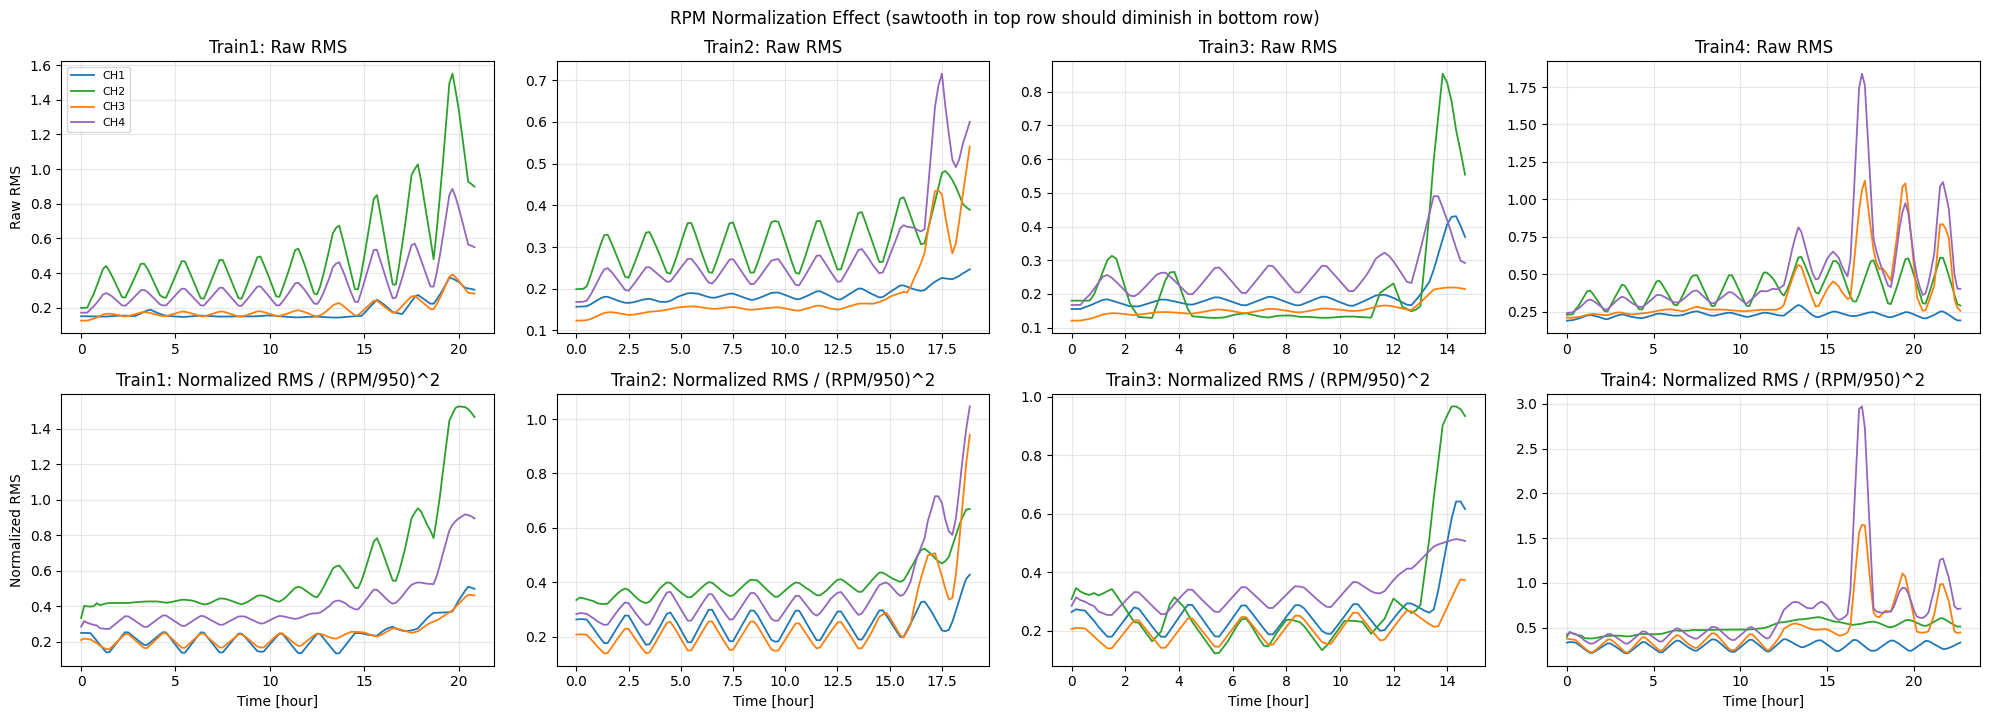

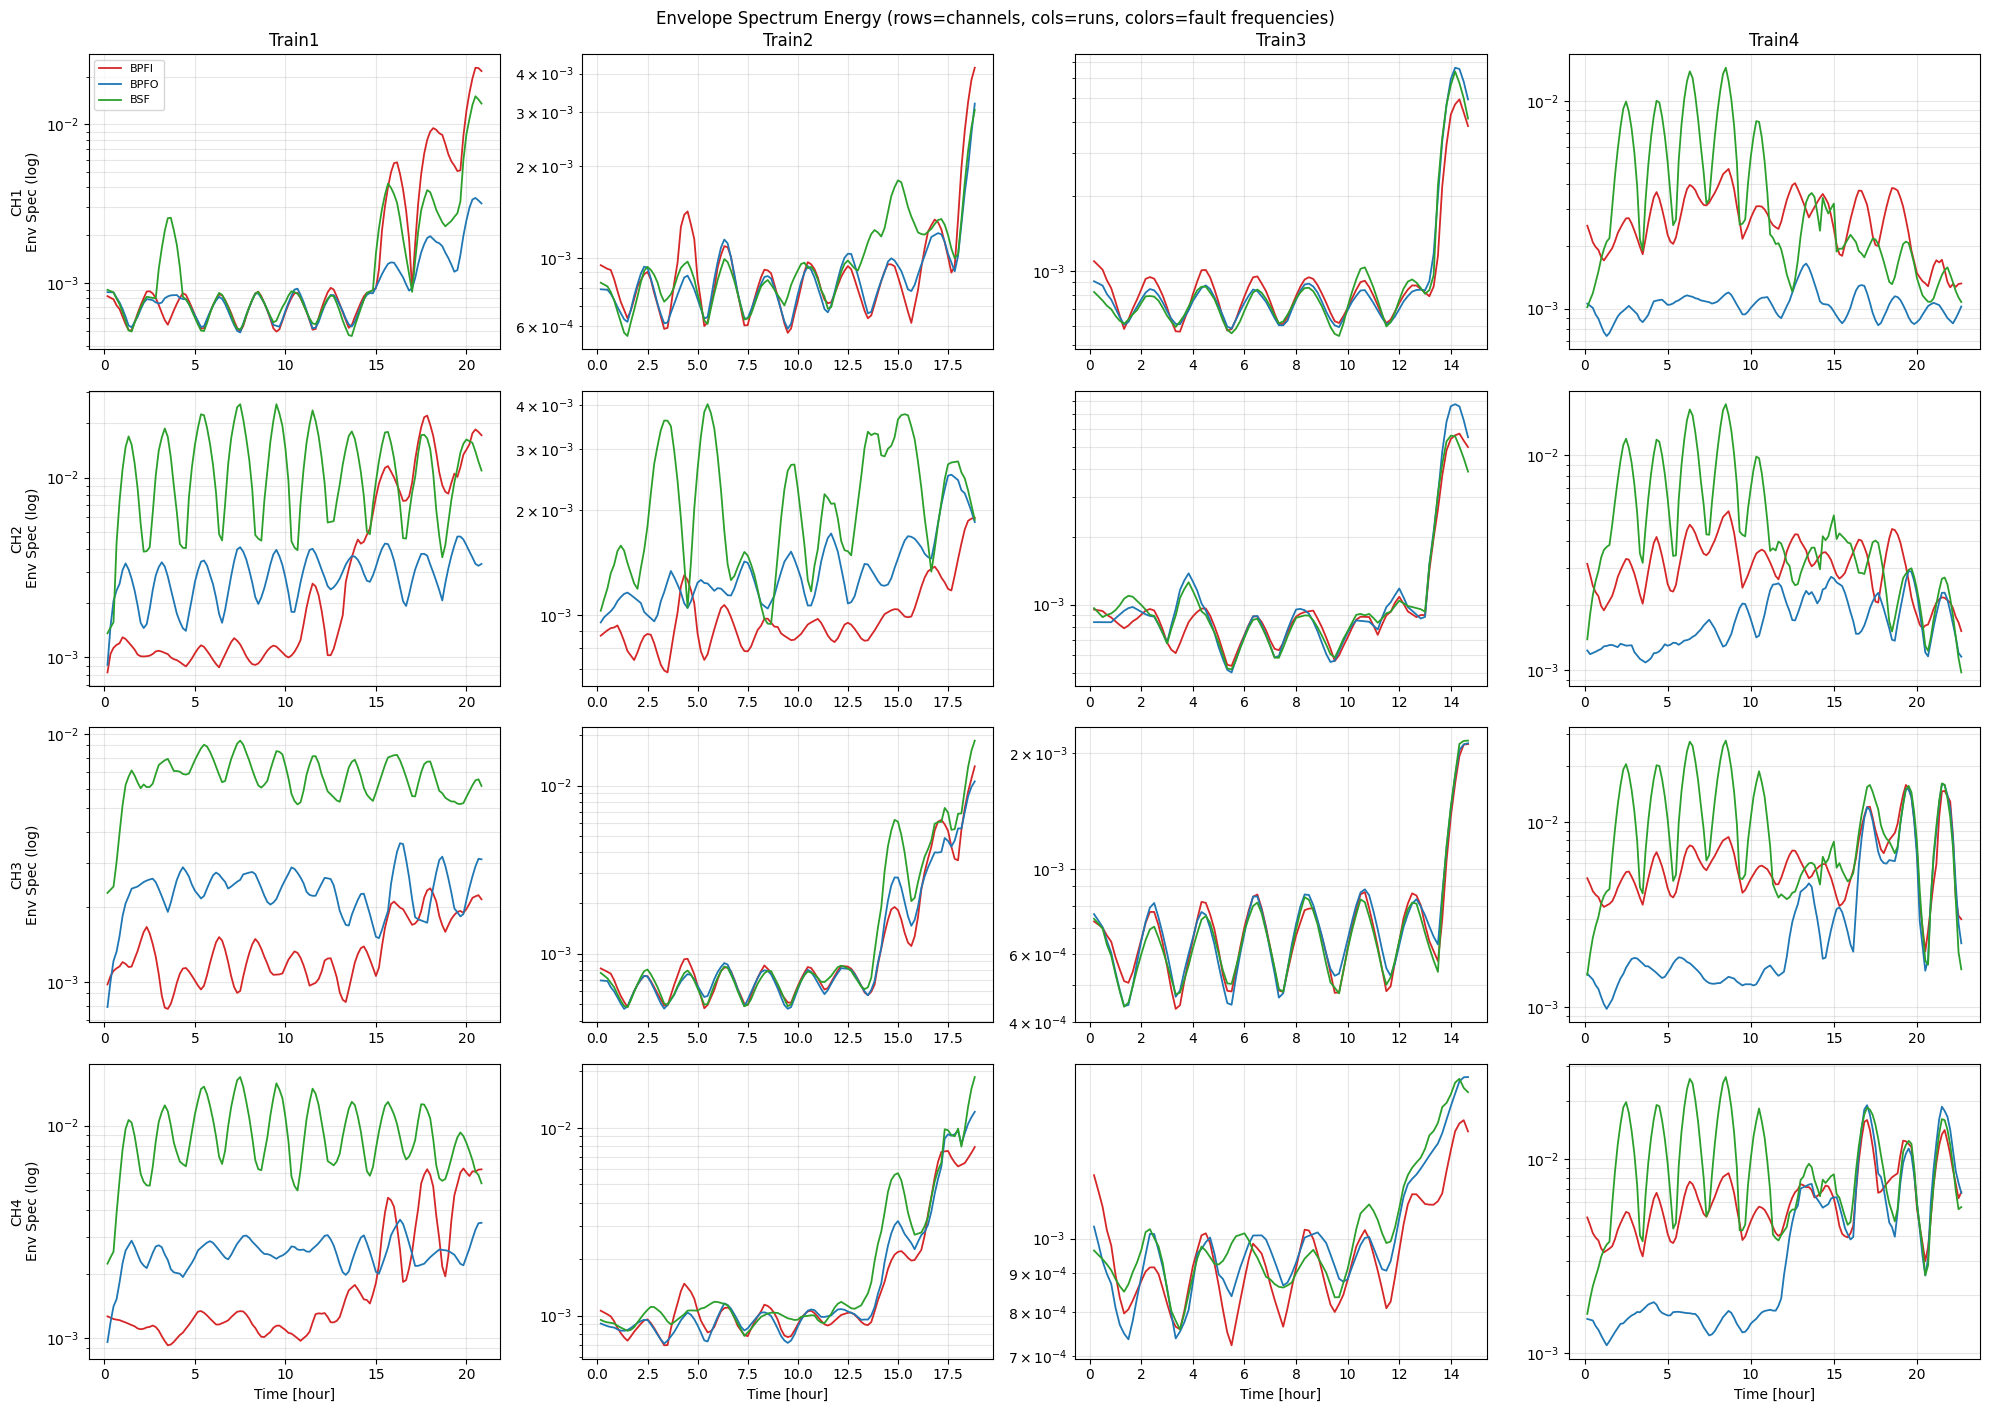

In [11]:
import matplotlib.pyplot as plt
import numpy as np

def smooth(s, w=5):
    return s.rolling(w, center=True, min_periods=1).median().rolling(w, min_periods=1).mean()

runs = ['Train1', 'Train2', 'Train3', 'Train4']
ch_colors = {'CH1': 'tab:blue', 'CH2': 'tab:green', 'CH3': 'tab:orange', 'CH4': 'tab:purple'}
freq_colors = {'BPFI': 'tab:red', 'BPFO': 'tab:blue', 'BSF': 'tab:green'}

# =========================================
# Comparison 1: Raw RMS vs Normalized RMS
# =========================================
fig, axes = plt.subplots(2, 4, figsize=(20, 7), sharex=False)
for col, run in enumerate(runs):
    sub = feature_df[feature_df['run'] == run].reset_index(drop=True)
    t = sub['time_sec'] / 3600

    ax = axes[0, col]
    for ch in ['CH1', 'CH2', 'CH3', 'CH4']:
        ax.plot(t, smooth(sub[f'{ch}_RMS']), color=ch_colors[ch], lw=1.3, label=ch)
    ax.set_title(f'{run}: Raw RMS')
    if col == 0:
        ax.set_ylabel('Raw RMS')
        ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    ax = axes[1, col]
    for ch in ['CH1', 'CH2', 'CH3', 'CH4']:
        ax.plot(t, smooth(sub[f'{ch}_RMS_norm']), color=ch_colors[ch], lw=1.3, label=ch)
    ax.set_title(f'{run}: Normalized RMS / (RPM/950)^2')
    ax.set_xlabel('Time [hour]')
    if col == 0:
        ax.set_ylabel('Normalized RMS')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.suptitle('RPM Normalization Effect (sawtooth in top row should diminish in bottom row)', y=1.02)
plt.show()


# =========================================
# Comparison 2: BPFI / BPFO / BSF per channel
# =========================================
fig, axes = plt.subplots(4, 4, figsize=(20, 14), sharex=False)
for col, run in enumerate(runs):
    sub = feature_df[feature_df['run'] == run].reset_index(drop=True)
    sub = sub[~sub['is_startup']].reset_index(drop=True)
    t = sub['time_sec'] / 3600

    for row_idx, ch in enumerate(['CH1', 'CH2', 'CH3', 'CH4']):
        ax = axes[row_idx, col]
        for freq_name in ['BPFI', 'BPFO', 'BSF']:
            ax.plot(t, smooth(sub[f'{ch}_{freq_name}_norm']),
                    color=freq_colors[freq_name], lw=1.3, label=freq_name)
        ax.set_yscale('log')
        if row_idx == 0:
            ax.set_title(run)
        if col == 0:
            ax.set_ylabel(f'{ch}\nEnv Spec (log)')
        if row_idx == 3:
            ax.set_xlabel('Time [hour]')
        if row_idx == 0 and col == 0:
            ax.legend(fontsize=8, loc='upper left')
        ax.grid(alpha=0.3, which='both')

plt.tight_layout()
plt.suptitle('Envelope Spectrum Energy (rows=channels, cols=runs, colors=fault frequencies)', y=1.005)
plt.show()

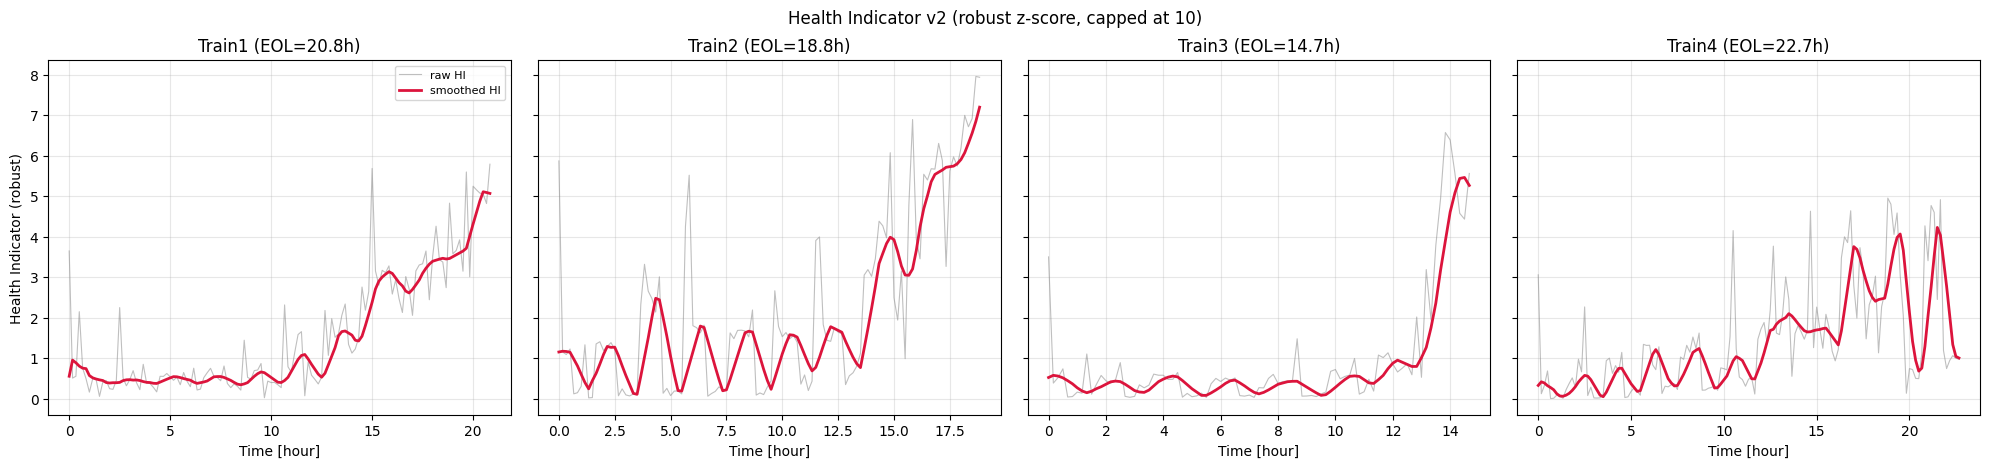

        hi_start  hi_end  hi_max  hi_ratio
run                                       
Train1     1.522   5.181   5.793      3.40
Train2     1.892   7.309   7.962      3.86
Train3     1.036   5.307   6.576      5.12
Train4     0.838   0.944   4.955      1.13


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# dynamic range가 큰 feature는 log1p 먼저
LOG_FEATS = []
for ch in ['CH1','CH2','CH3','CH4']:
    LOG_FEATS += [f'{ch}_Kurt',
                  f'{ch}_BPFI_norm', f'{ch}_BPFO_norm', f'{ch}_BSF_norm']
LIN_FEATS = []
for ch in ['CH1','CH2','CH3','CH4']:
    LIN_FEATS += [f'{ch}_RMS_norm', f'{ch}_P2P_norm', f'{ch}_Std_norm',
                  f'{ch}_CrestF']

def compute_hi_robust(df, healthy_ratio=0.2, z_clip=10.0):
    out = []
    for run, sub in df.groupby('run'):
        sub = sub.sort_values('file_idx').reset_index(drop=True)

        # log 변환된 feature 컬럼들 생성
        X_log = np.log1p(sub[LOG_FEATS].clip(lower=0))  # 음수 방지
        X_lin = sub[LIN_FEATS]
        X = pd.concat([X_log.add_prefix('log_'), X_lin], axis=1)

        # Healthy 구간: 처음 20% + startup 제외
        mask_healthy = (~sub['is_startup']) & (sub['file_idx'] < len(sub)*healthy_ratio)

        # Robust 통계: median + MAD (×1.4826으로 std 스케일에 맞춤)
        med = X.loc[mask_healthy].median()
        mad = (X.loc[mask_healthy] - med).abs().median() * 1.4826
        mad = mad.replace(0, 1e-6)

        # Z-score, 양의 방향만 (열화는 증가), clip
        z = ((X - med) / mad).clip(lower=0, upper=z_clip)

        # 평균 결합
        hi = z.mean(axis=1)

        sub = sub.copy()
        sub['HI'] = hi.values
        out.append(sub)
    return pd.concat(out, ignore_index=True)

feature_df = compute_hi_robust(feature_df)

# -------- 시각화 --------
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5), sharey=True)
for col, run in enumerate(['Train1','Train2','Train3','Train4']):
    sub = feature_df[feature_df['run']==run].reset_index(drop=True)
    t_hr = sub['time_sec']/3600
    hi_smooth = sub['HI'].rolling(5, center=True, min_periods=1).median() \
                        .rolling(5, min_periods=1).mean()
    axes[col].plot(t_hr, sub['HI'], color='gray', alpha=0.5, lw=0.8, label='raw HI')
    axes[col].plot(t_hr, hi_smooth, color='crimson', lw=2, label='smoothed HI')
    axes[col].set_title(f'{run} (EOL={sub["time_sec"].iloc[-1]/3600:.1f}h)')
    axes[col].set_xlabel('Time [hour]')
    axes[col].grid(alpha=0.3)
    if col == 0:
        axes[col].set_ylabel('Health Indicator (robust)')
        axes[col].legend(fontsize=8)
plt.tight_layout()
plt.suptitle('Health Indicator v2 (robust z-score, capped at 10)', y=1.03)
plt.show()

summary = feature_df.groupby('run').agg(
    hi_start=('HI', lambda s: s.iloc[:5].mean()),
    hi_end=('HI',   lambda s: s.iloc[-5:].mean()),
    hi_max=('HI',   'max'),
).round(3)
summary['hi_ratio'] = (summary['hi_end'] / summary['hi_start'].replace(0, 1e-9)).round(2)
print(summary)

Train4 HI peak at file_idx=129, time=21.5h
Train4 before: 137 rows, after: 130 rows (7 removed)


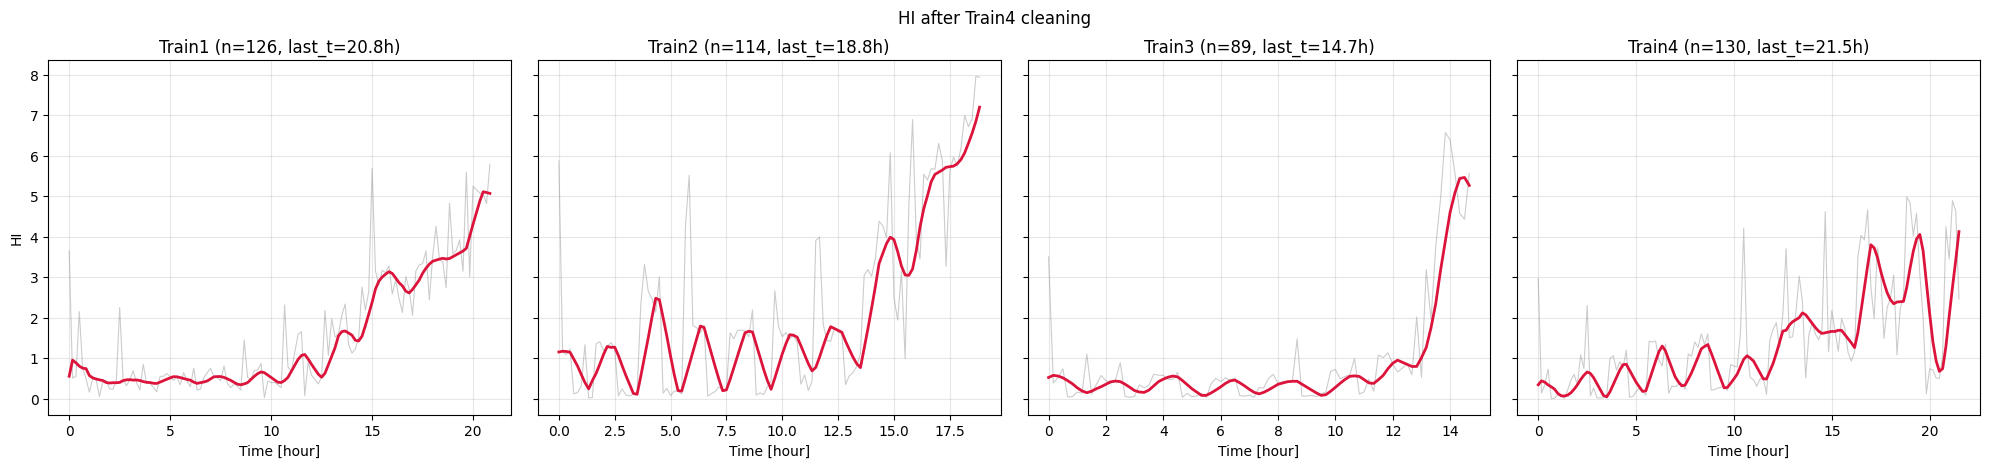


Cleaned shape: (459, 67)
run
Train1    126
Train2    114
Train3     89
Train4    130
dtype: int64


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ========================================
# Train4 클리닝: HI peak 이후 제외
# ========================================
# Train4 HI의 smoothed 값에서 가장 큰 peak를 찾고, 그 이후는 제외
train4 = feature_df[feature_df['run']=='Train4'].copy().reset_index(drop=True)
hi_smooth_t4 = train4['HI'].rolling(5, center=True, min_periods=1).median() \
                           .rolling(5, min_periods=1).mean()

# smoothed HI가 최대가 되는 지점 찾기
peak_idx = hi_smooth_t4.idxmax()
peak_time_hr = train4.loc[peak_idx, 'time_sec'] / 3600
print(f"Train4 HI peak at file_idx={peak_idx}, time={peak_time_hr:.1f}h")

# Peak 시점까지만 유지 (그 이후는 버림)
train4_clean = train4.iloc[:peak_idx+1].copy()
print(f"Train4 before: {len(train4)} rows, after: {len(train4_clean)} rows "
      f"({len(train4)-len(train4_clean)} removed)")

# 다른 run들과 다시 합치기
other_runs = feature_df[feature_df['run']!='Train4']
feature_df_clean = pd.concat([other_runs, train4_clean], ignore_index=True)
feature_df_clean = feature_df_clean.sort_values(['run','file_idx']).reset_index(drop=True)

# ========================================
# RUL 재계산 (Train4의 EOL이 바뀌었으므로)
# ========================================
# 이제 Train4의 "관측된 EOL"은 cleaned 마지막 시점으로 봄
# 다만 이건 실제 EOL이 아니니, Train4의 RUL 라벨은 신뢰도 낮음
# → Train4는 validation 용 sanity check 정도로만 쓰고, 실제 학습은 1/2/3 중심

# 원본 rul_sec는 그대로 두고, 추가 정보만 태깅
feature_df_clean['is_train4_tail_removed'] = (
    (feature_df_clean['run']=='Train4')  # 나중에 식별용
)

# ========================================
# HI 재계산 (clean 데이터 기준)
# ========================================
feature_df_clean = compute_hi_robust(feature_df_clean)

# ========================================
# 최종 확인 시각화
# ========================================
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5), sharey=True)
for col, run in enumerate(['Train1','Train2','Train3','Train4']):
    sub = feature_df_clean[feature_df_clean['run']==run].reset_index(drop=True)
    t_hr = sub['time_sec']/3600
    hi_smooth = sub['HI'].rolling(5, center=True, min_periods=1).median() \
                        .rolling(5, min_periods=1).mean()
    axes[col].plot(t_hr, sub['HI'], color='gray', alpha=0.4, lw=0.8)
    axes[col].plot(t_hr, hi_smooth, color='crimson', lw=2)
    axes[col].set_title(f'{run} (n={len(sub)}, last_t={sub["time_sec"].iloc[-1]/3600:.1f}h)')
    axes[col].set_xlabel('Time [hour]')
    axes[col].grid(alpha=0.3)
    if col == 0:
        axes[col].set_ylabel('HI')
plt.tight_layout()
plt.suptitle('HI after Train4 cleaning', y=1.03)
plt.show()

# 저장
feature_df_clean.to_csv('feature_df_clean.csv', index=False)
print(f"\nCleaned shape: {feature_df_clean.shape}")
print(feature_df_clean.groupby('run').size())

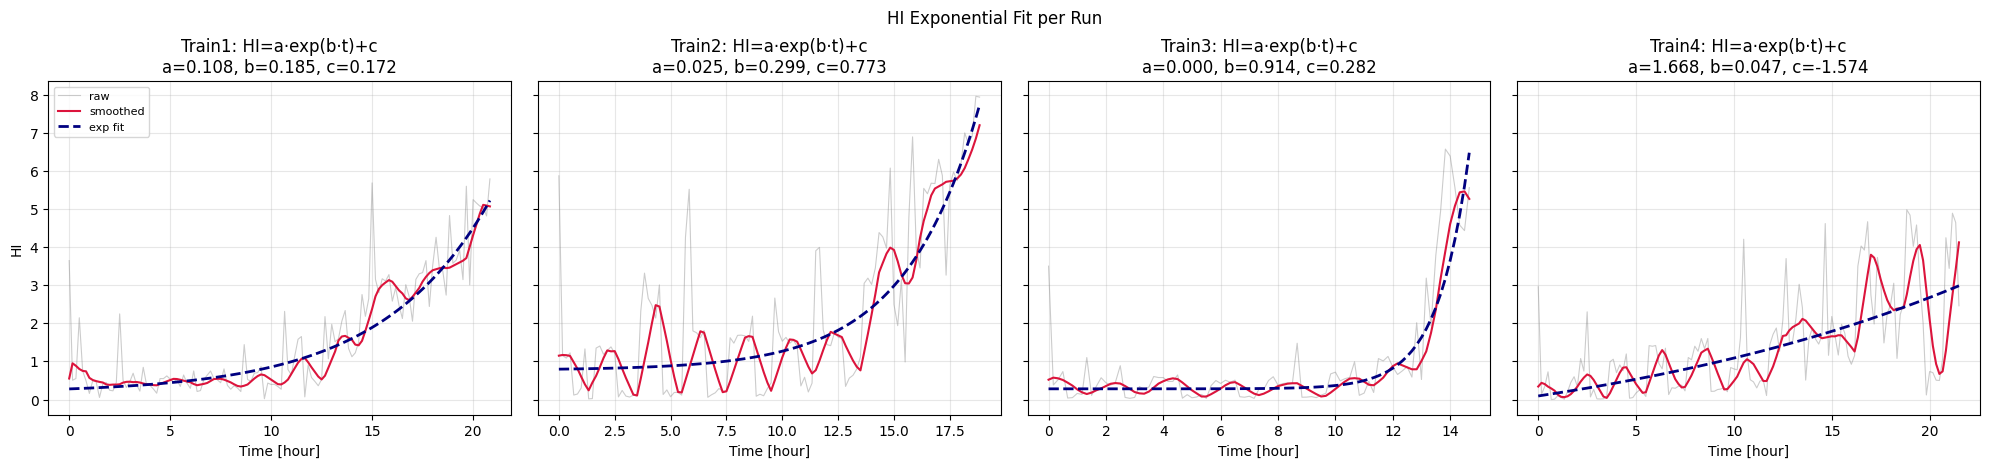


=== Fit Parameters ===
            a      b      c  hi_at_eol  eol_hr
Train1  0.108  0.185  0.172      5.227  20.833
Train2  0.025  0.299  0.773      7.737  18.833
Train3  0.000  0.914  0.282      6.480  14.667
Train4  1.668  0.047 -1.574      2.988  21.500

평균 EOL 시점 HI (fit 기준): 5.608
이 값을 'HI가 이만큼 되면 EOL'의 임계값으로 사용


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 외삽 모델: HI = a * exp(b * t) + c
def exp_model(t, a, b, c):
    return a * np.exp(b * t) + c

# 각 run의 HI 곡선에 fit
fit_results = {}
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5), sharey=True)

for col, run in enumerate(['Train1','Train2','Train3','Train4']):
    sub = feature_df_clean[feature_df_clean['run']==run].reset_index(drop=True)
    t_hr = (sub['time_sec']/3600).values
    hi = sub['HI'].values
    # smoothing으로 fitting 안정화
    hi_smooth = pd.Series(hi).rolling(5, center=True, min_periods=1).median() \
                              .rolling(5, min_periods=1).mean().values

    try:
        # 초기값: healthy baseline ≈ c, 후기 성장률 b ≈ 0.2
        p0 = [0.1, 0.2, hi_smooth[:10].mean()]
        # 파라미터 bounds: a>0, b>0 (단조증가 보장), c는 자유
        bounds = ([1e-6, 1e-4, -5], [10, 1.0, 5])
        popt, _ = curve_fit(exp_model, t_hr, hi_smooth, p0=p0, bounds=bounds, maxfev=10000)
        a, b, c = popt
        hi_fit = exp_model(t_hr, a, b, c)

        # EOL 시점의 fit된 HI 값
        hi_at_eol = exp_model(t_hr[-1], a, b, c)
        fit_results[run] = {'a':a, 'b':b, 'c':c, 'hi_at_eol':hi_at_eol, 'eol_hr':t_hr[-1]}

        axes[col].plot(t_hr, hi, color='gray', alpha=0.4, lw=0.8, label='raw')
        axes[col].plot(t_hr, hi_smooth, color='crimson', lw=1.5, label='smoothed')
        axes[col].plot(t_hr, hi_fit, color='navy', lw=2, linestyle='--', label='exp fit')
        axes[col].set_title(f'{run}: HI=a·exp(b·t)+c\na={a:.3f}, b={b:.3f}, c={c:.3f}')
        axes[col].set_xlabel('Time [hour]')
        if col == 0:
            axes[col].set_ylabel('HI')
            axes[col].legend(fontsize=8, loc='upper left')
        axes[col].grid(alpha=0.3)
    except Exception as e:
        print(f"{run} fitting failed: {e}")

plt.tight_layout()
plt.suptitle('HI Exponential Fit per Run', y=1.03)
plt.show()

# 결과 요약 테이블
fit_df = pd.DataFrame(fit_results).T
print("\n=== Fit Parameters ===")
print(fit_df.round(3))

# 해석: EOL 임계값 (4개 run의 "fit된 HI at EOL"의 평균)
threshold_hi = fit_df['hi_at_eol'].mean()
print(f"\n평균 EOL 시점 HI (fit 기준): {threshold_hi:.3f}")
print("이 값을 'HI가 이만큼 되면 EOL'의 임계값으로 사용")

HI_global baseline 저장됨: hi_baseline.csv


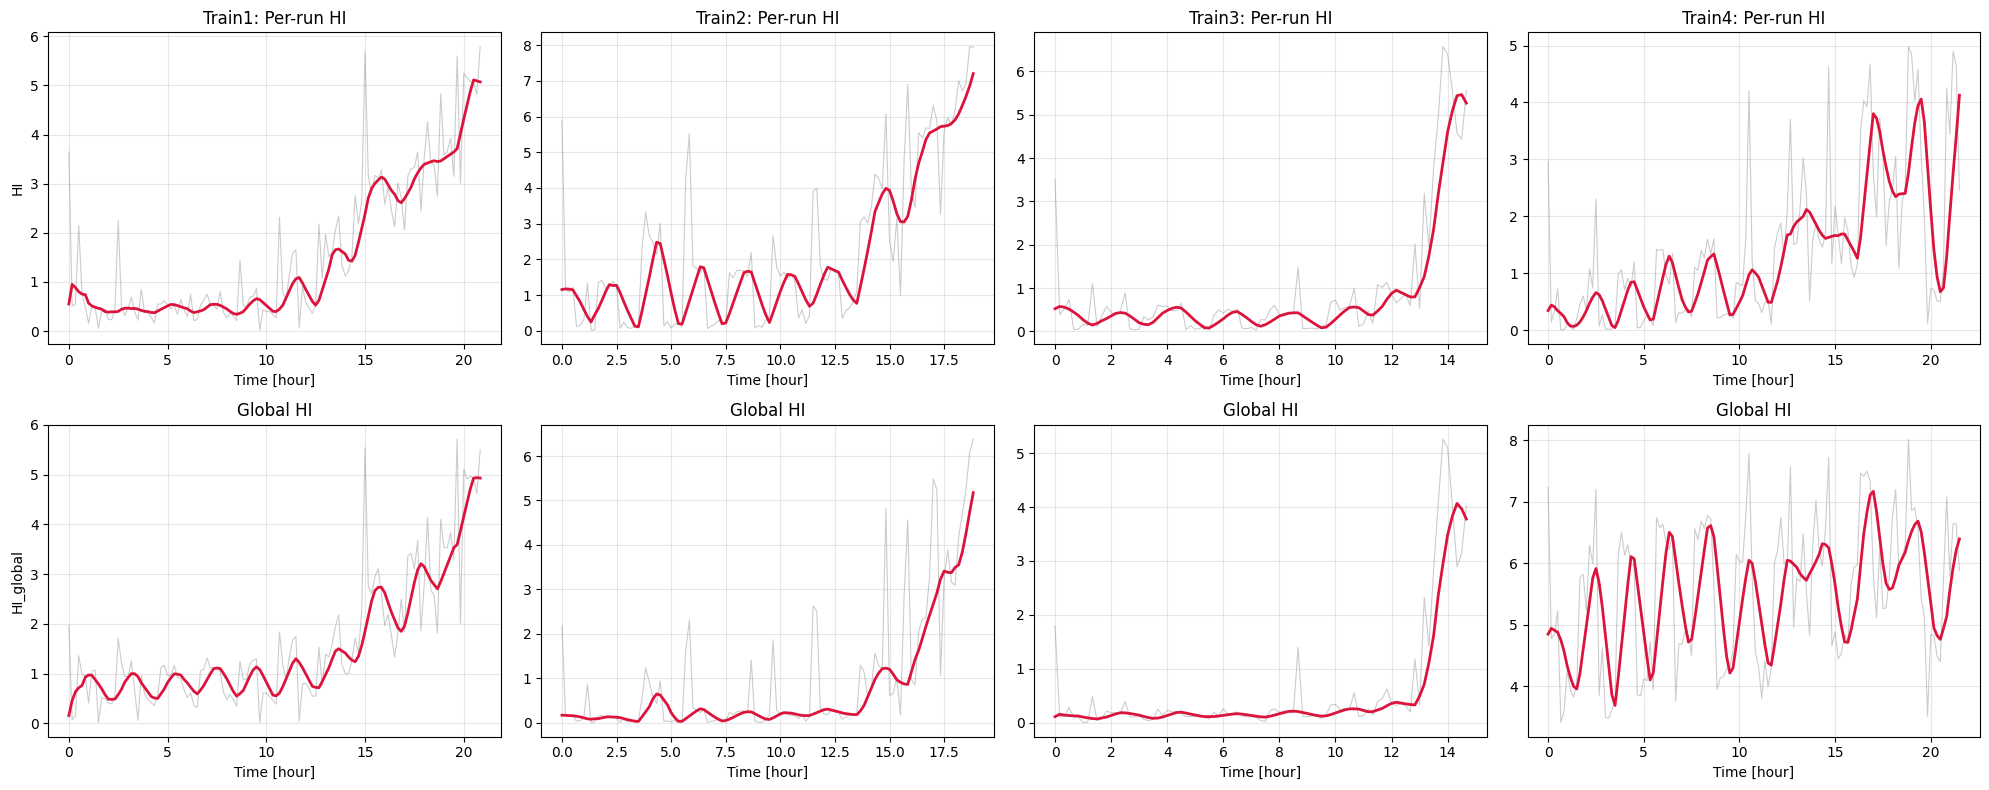

        hi_start  hi_end  hi_global_start  hi_global_end
run                                                     
Train1     1.522   5.181            0.907          4.983
Train2     1.892   7.309            0.535          5.320
Train3     1.036   5.307            0.479          3.839
Train4     0.834   3.939            5.098          6.407


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Global healthy baseline: 4개 run의 초기 20% (startup 제외) 데이터 모두 합쳐서 기준 계산
LOG_FEATS = [f'{ch}_{f}' for ch in ['CH1','CH2','CH3','CH4']
             for f in ['Kurt','BPFI_norm','BPFO_norm','BSF_norm']]
LIN_FEATS = [f'{ch}_{f}' for ch in ['CH1','CH2','CH3','CH4']
             for f in ['RMS_norm','P2P_norm','Std_norm','CrestF']]

def compute_hi_global(df, healthy_ratio=0.2, z_clip=10.0):
    # 1) 각 run의 healthy 구간 샘플들을 모두 모음
    healthy_parts = []
    for run, sub in df.groupby('run'):
        sub = sub.sort_values('file_idx').reset_index(drop=True)
        mask = (~sub['is_startup']) & (sub['file_idx'] < len(sub)*healthy_ratio)
        healthy_parts.append(sub.loc[mask])
    healthy_all = pd.concat(healthy_parts, ignore_index=True)

    # 2) Global median/MAD 계산
    X_log = np.log1p(healthy_all[LOG_FEATS].clip(lower=0)).add_prefix('log_')
    X_lin = healthy_all[LIN_FEATS]
    X_healthy = pd.concat([X_log, X_lin], axis=1)

    global_med = X_healthy.median()
    global_mad = (X_healthy - global_med).abs().median() * 1.4826
    global_mad = global_mad.replace(0, 1e-6)

    # 3) 전체 데이터에 같은 통계 적용
    out = []
    for run, sub in df.groupby('run'):
        sub = sub.sort_values('file_idx').reset_index(drop=True).copy()
        X_log_all = np.log1p(sub[LOG_FEATS].clip(lower=0)).add_prefix('log_')
        X_lin_all = sub[LIN_FEATS]
        X_all = pd.concat([X_log_all, X_lin_all], axis=1)

        z = ((X_all - global_med) / global_mad).clip(lower=0, upper=z_clip)
        sub['HI_global'] = z.mean(axis=1).values
        out.append(sub)
    return pd.concat(out, ignore_index=True), global_med, global_mad

feature_df_clean, g_med, g_mad = compute_hi_global(feature_df_clean)

# baseline 저장 (validation 때 같은 값 쓰기 위해)
pd.DataFrame({'median': g_med, 'mad': g_mad}).to_csv('hi_baseline.csv')
print(f"HI_global baseline 저장됨: hi_baseline.csv")

# 시각화: 기존 HI vs Global HI
fig, axes = plt.subplots(2, 4, figsize=(20, 8), sharex=False)
for col, run in enumerate(['Train1','Train2','Train3','Train4']):
    sub = feature_df_clean[feature_df_clean['run']==run].reset_index(drop=True)
    t_hr = sub['time_sec']/3600

    for row, (hi_col, title) in enumerate([('HI','Per-run HI'),('HI_global','Global HI')]):
        ax = axes[row, col]
        hi_raw = sub[hi_col]
        hi_smooth = hi_raw.rolling(5, center=True, min_periods=1).median() \
                          .rolling(5, min_periods=1).mean()
        ax.plot(t_hr, hi_raw, color='gray', alpha=0.4, lw=0.8)
        ax.plot(t_hr, hi_smooth, color='crimson', lw=2)
        if row == 0:
            ax.set_title(f'{run}: {title}')
        else:
            ax.set_title(title)
        ax.set_xlabel('Time [hour]')
        if col == 0:
            ax.set_ylabel(hi_col)
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 두 HI의 EOL 시점 값 비교
summary = feature_df_clean.groupby('run').agg(
    hi_start=('HI', lambda s: s.iloc[:5].mean()),
    hi_end=('HI', lambda s: s.iloc[-5:].mean()),
    hi_global_start=('HI_global', lambda s: s.iloc[:5].mean()),
    hi_global_end=('HI_global', lambda s: s.iloc[-5:].mean()),
).round(3)
print(summary)

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# Step 2-1: 시계열 관련 feature 추가
# ==========================================
# "현재 값" 뿐 아니라 "최근 변화 추세"도 중요
def add_temporal_features(df, cols, windows=[5, 10]):
    """각 컬럼에 대해 rolling mean, std, slope 추가"""
    out = df.copy()
    for run, sub in out.groupby('run'):
        idx = sub.index
        for col in cols:
            for w in windows:
                # Rolling mean (최근 w개 평균)
                out.loc[idx, f'{col}_rmean{w}'] = sub[col].rolling(w, min_periods=1).mean().values
                # Rolling std (최근 w개 변동성)
                out.loc[idx, f'{col}_rstd{w}']  = sub[col].rolling(w, min_periods=1).std().fillna(0).values
                # Slope: 최근 w개의 선형 기울기 (정규화된 시간축)
                def slope(x):
                    if len(x) < 2:
                        return 0.0
                    t = np.arange(len(x))
                    return float(np.polyfit(t, x, 1)[0])
                out.loc[idx, f'{col}_slope{w}'] = sub[col].rolling(w, min_periods=2).apply(slope, raw=True).fillna(0).values
    return out

# 시계열 feature를 추가할 컬럼들: HI 관련 + 주요 feature 몇 개
temporal_base_cols = ['HI', 'HI_global', 'temp_front', 'temp_rear', 'torque',
                      'CH1_RMS_norm','CH2_RMS_norm','CH3_RMS_norm','CH4_RMS_norm']

feature_df_ext = add_temporal_features(feature_df_clean, temporal_base_cols)
print(f"Extended feature_df shape: {feature_df_ext.shape}")
print(f"새로 추가된 feature 예시: {[c for c in feature_df_ext.columns if 'slope' in c][:5]}")

# ==========================================
# Step 2-2: 학습용 X, y, group 정의
# ==========================================
# X: feature 컬럼들만
# y: rul_sec (초 단위 RUL)
# group: run 이름 (Leave-One-Run-Out CV에 사용)

drop_cols = ['run', 'file_idx', 'time_sec', 'rul_sec', 'is_startup', 'is_train4_tail_removed']
feature_cols = [c for c in feature_df_ext.columns if c not in drop_cols]

# startup 구간은 학습에서 제외 (운전 조건이 비정상)
mask = ~feature_df_ext['is_startup']
X = feature_df_ext.loc[mask, feature_cols].copy()
y = feature_df_ext.loc[mask, 'rul_sec'].values.astype(np.float32)
groups = feature_df_ext.loc[mask, 'run'].values

print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"Runs: {np.unique(groups, return_counts=True)}")

Extended feature_df shape: (459, 122)
새로 추가된 feature 예시: ['HI_slope5', 'HI_slope10', 'HI_global_slope5', 'HI_global_slope10', 'temp_front_slope5']
X shape: (455, 116), y shape: (455,)
Runs: (array(['Train1', 'Train2', 'Train3', 'Train4'], dtype=object), array([125, 113,  88, 129]))


In [20]:
def challenge_score(y_true, y_pred):
    """
    챌린지 공식대로 계산:
      Er_i = 100 * (ActRUL - PredRUL) / ActRUL
      A_RUL = exp(-ln(0.5) * Er/20) if Er <= 0 (과대예측, 페널티 큼)
              exp(+ln(0.5) * Er/50) if Er >  0 (과소예측, 페널티 작음)
      Final = mean(A_RUL)
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    # 실제 RUL이 0이면 오차 정의 안 됨 → 제외 (EOL 시점)
    valid = y_true > 0
    yt, yp = y_true[valid], y_pred[valid]
    Er = 100.0 * (yt - yp) / yt   # Er<=0: 과대예측, Er>0: 과소예측
    score = np.where(
        Er <= 0,
        np.exp(-np.log(0.5) * Er / 20.0),  # 과대예측 페널티
        np.exp( np.log(0.5) * Er / 50.0),  # 과소예측 페널티
    )
    return float(score.mean()), Er

def print_score(y_true, y_pred, label=""):
    score, Er = challenge_score(y_true, y_pred)
    n_over  = (Er < 0).sum()   # 과대예측 개수
    n_under = (Er > 0).sum()
    print(f"  [{label}] Score={score:.4f}  |  과대예측={n_over}, 과소예측={n_under}  "
          f"|  Er 평균={Er.mean():.1f}%, Er 중앙={np.median(Er):.1f}%")
    return score

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[147]	valid_0's rmse: 13140.7

=== Test on Train1 ===
  [Train1] Score=0.4451  |  과대예측=58, 과소예측=67  |  Er 평균=-36.3%, Er 중앙=9.5%
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[167]	valid_0's rmse: 17326.2

=== Test on Train2 ===
  [Train2] Score=0.4563  |  과대예측=61, 과소예측=52  |  Er 평균=-153.1%, Er 중앙=-13.3%
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's rmse: 21689.4

=== Test on Train3 ===
  [Train3] Score=0.3555  |  과대예측=66, 과소예측=22  |  Er 평균=-324.1%, Er 중앙=-49.0%
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[25]	valid_0's rmse: 20425.6

=== Test on Train4 ===
  [Train4] Score=0.4312  |  과대예측=20, 과소예측=109  |  Er 평균=38.7%, Er 중앙=60.2%


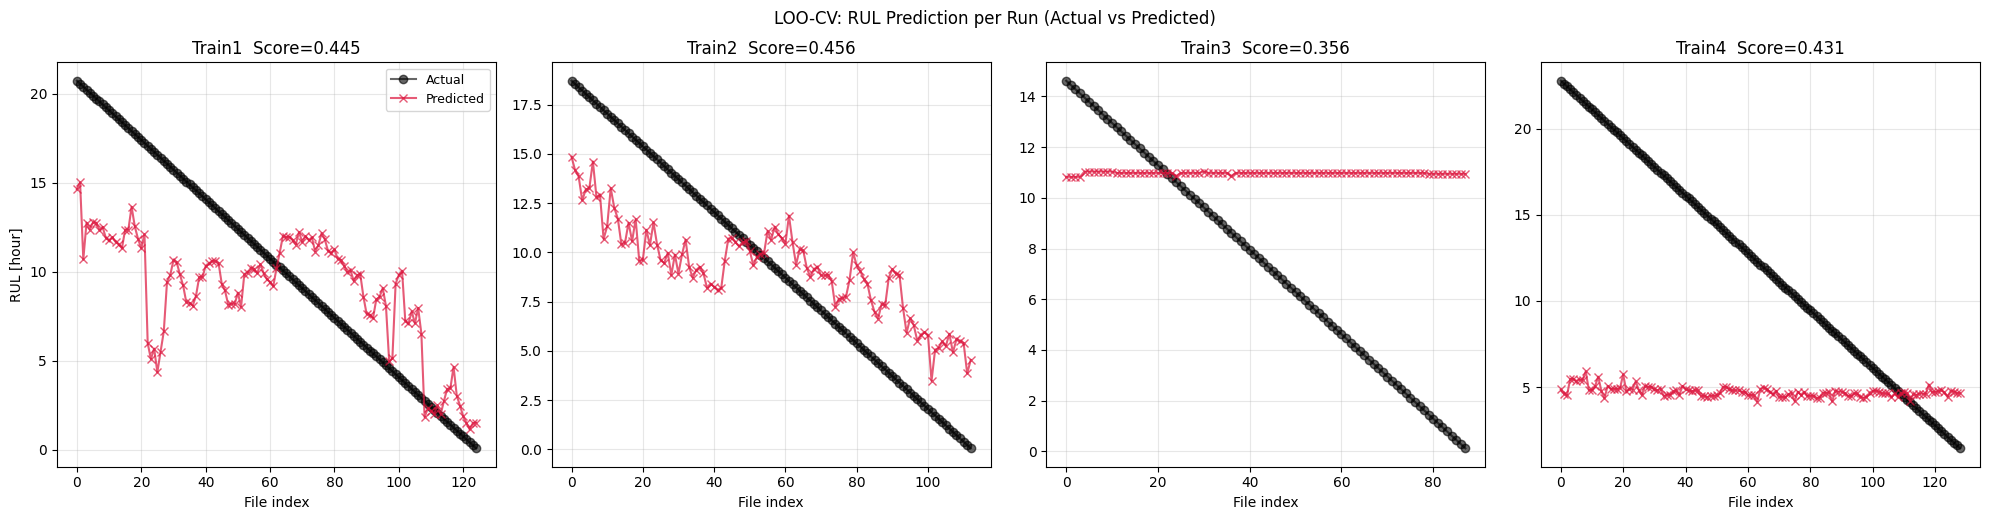


  LOO-CV 평균 Score = 0.4220  (1.0이 만점)


In [21]:
# ==========================================
# Step 4: Leave-One-Run-Out Cross-Validation
# ==========================================
# 3개 run으로 학습, 나머지 1개로 평가 (총 4번)
# 이게 validation 데이터와 가장 비슷한 시나리오

lgb_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.03,
    'num_leaves': 31,
    'max_depth': 6,
    'min_child_samples': 5,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'seed': 42,
}

all_results = {}
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=False)

for col, test_run in enumerate(['Train1','Train2','Train3','Train4']):
    train_mask = (groups != test_run)
    test_mask  = (groups == test_run)

    X_tr, y_tr = X[train_mask], y[train_mask]
    X_te, y_te = X[test_mask],  y[test_mask]

    # Train 내에서 한 run을 val로 떼서 early stopping
    val_run = [r for r in np.unique(groups[train_mask])][0]
    val_mask_inner = (groups[train_mask] == val_run)
    X_tr_inner = X_tr[~val_mask_inner]
    y_tr_inner = y_tr[~val_mask_inner]
    X_val = X_tr[val_mask_inner]
    y_val = y_tr[val_mask_inner]

    dtrain = lgb.Dataset(X_tr_inner, label=y_tr_inner)
    dval   = lgb.Dataset(X_val, label=y_val, reference=dtrain)

    model = lgb.train(
        lgb_params,
        dtrain,
        num_boost_round=2000,
        valid_sets=[dval],
        callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)],
    )

    y_pred = model.predict(X_te)
    # RUL은 음수가 될 수 없음
    y_pred = np.clip(y_pred, 0, None)

    print(f"\n=== Test on {test_run} ===")
    score = print_score(y_te, y_pred, label=test_run)
    all_results[test_run] = {'score': score, 'model': model, 'y_true': y_te, 'y_pred': y_pred}

    # 시각화: 실제 RUL vs 예측 RUL
    idx = np.arange(len(y_te))
    axes[col].plot(idx, y_te/3600, 'o-', color='black', alpha=0.6, label='Actual', lw=1.5)
    axes[col].plot(idx, y_pred/3600, 'x-', color='crimson', alpha=0.7, label='Predicted', lw=1.5)
    axes[col].set_title(f'{test_run}  Score={score:.3f}')
    axes[col].set_xlabel('File index')
    axes[col].set_ylabel('RUL [hour]' if col == 0 else '')
    axes[col].grid(alpha=0.3)
    if col == 0:
        axes[col].legend(fontsize=9)

plt.tight_layout()
plt.suptitle('LOO-CV: RUL Prediction per Run (Actual vs Predicted)', y=1.03)
plt.show()

# 전체 평균 점수
mean_score = np.mean([v['score'] for v in all_results.values()])
print(f"\n{'='*50}")
print(f"  LOO-CV 평균 Score = {mean_score:.4f}  (1.0이 만점)")
print(f"{'='*50}")


=== Top 20 Features (Gain-based Importance, mean across 4 folds) ===
                              mean
temp_front_rmean10    1.305098e+11
temp_rear_rmean10     9.422762e+10
HI_rmean10            9.351744e+10
CH4_RMS_norm_rmean10  6.457320e+10
CH3_RMS               5.949833e+10
CH3_Kurt              4.006350e+10
HI_global_rstd10      3.796184e+10
torque_rstd10         3.208954e+10
CH2_CrestF            2.513518e+10
CH3_Std               2.202161e+10
CH1_Kurt              2.190624e+10
CH1_BSF               2.021702e+10
CH3_P2P               1.826699e+10
temp_front_rstd10     1.820486e+10
CH2_RMS_norm_rmean10  1.788054e+10
CH4_BPFO_norm         1.584313e+10
CH4_RMS_norm_rstd10   1.384240e+10
HI_rstd10             1.210558e+10
CH1_RMS_norm_rmean10  1.075421e+10
CH3_RMS_norm_rmean10  1.044440e+10


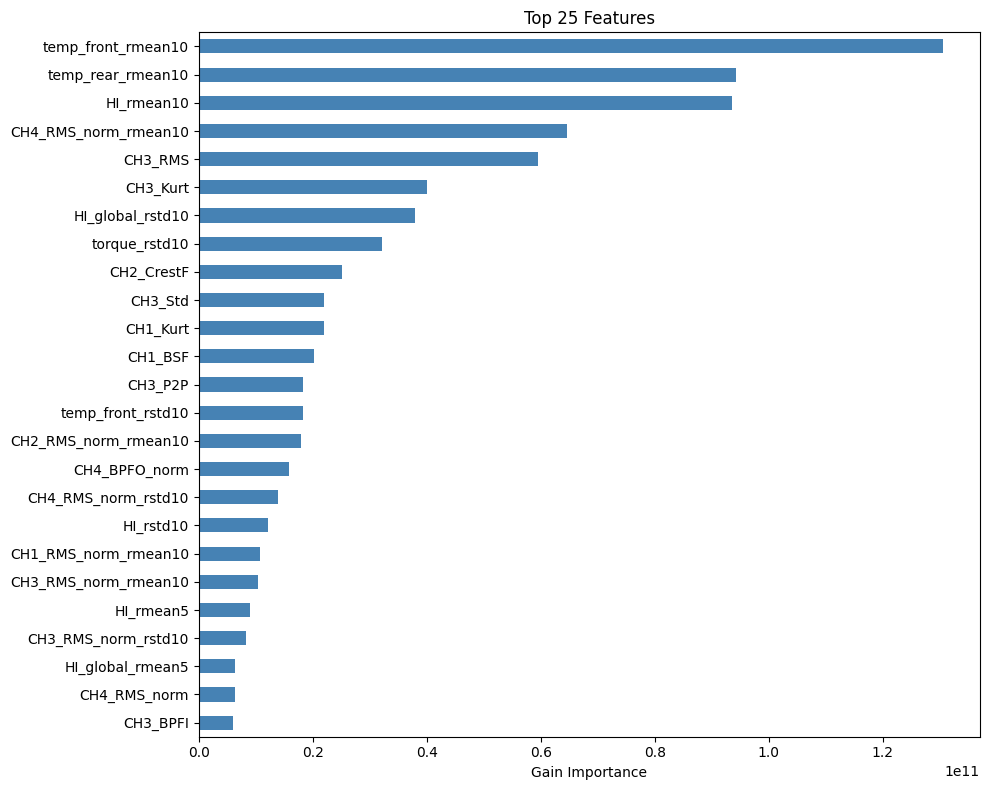

In [22]:
# 4개 모델의 feature importance 평균
importances = []
for run, res in all_results.items():
    imp = pd.Series(res['model'].feature_importance(importance_type='gain'),
                    index=feature_cols, name=run)
    importances.append(imp)

imp_df = pd.concat(importances, axis=1)
imp_df['mean'] = imp_df.mean(axis=1)
imp_df = imp_df.sort_values('mean', ascending=False)

print("\n=== Top 20 Features (Gain-based Importance, mean across 4 folds) ===")
print(imp_df.head(20)[['mean']].round(1))

# 시각화
fig, ax = plt.subplots(figsize=(10, 8))
imp_df.head(25)['mean'].iloc[::-1].plot.barh(ax=ax, color='steelblue')
ax.set_xlabel('Gain Importance')
ax.set_title('Top 25 Features')
plt.tight_layout()
plt.show()

Training until validation scores don't improve for 80 rounds
Early stopping, best iteration is:
[791]	valid_0's rmse: 0.766175

=== Test on Train1 ===
  [Train1] Score=0.4339  |  과대예측=58, 과소예측=67  |  Er 평균=-20.5%, Er 중앙=11.2%
Training until validation scores don't improve for 80 rounds
Early stopping, best iteration is:
[40]	valid_0's rmse: 0.689738

=== Test on Train2 ===
  [Train2] Score=0.4473  |  과대예측=63, 과소예측=50  |  Er 평균=-180.6%, Er 중앙=-12.0%
Training until validation scores don't improve for 80 rounds
Early stopping, best iteration is:
[15]	valid_0's rmse: 0.956688

=== Test on Train3 ===
  [Train3] Score=0.3757  |  과대예측=62, 과소예측=26  |  Er 평균=-253.2%, Er 중앙=-41.6%
Training until validation scores don't improve for 80 rounds
Early stopping, best iteration is:
[40]	valid_0's rmse: 0.685304

=== Test on Train4 ===
  [Train4] Score=0.3496  |  과대예측=1, 과소예측=128  |  Er 평균=78.9%, Er 중앙=87.0%


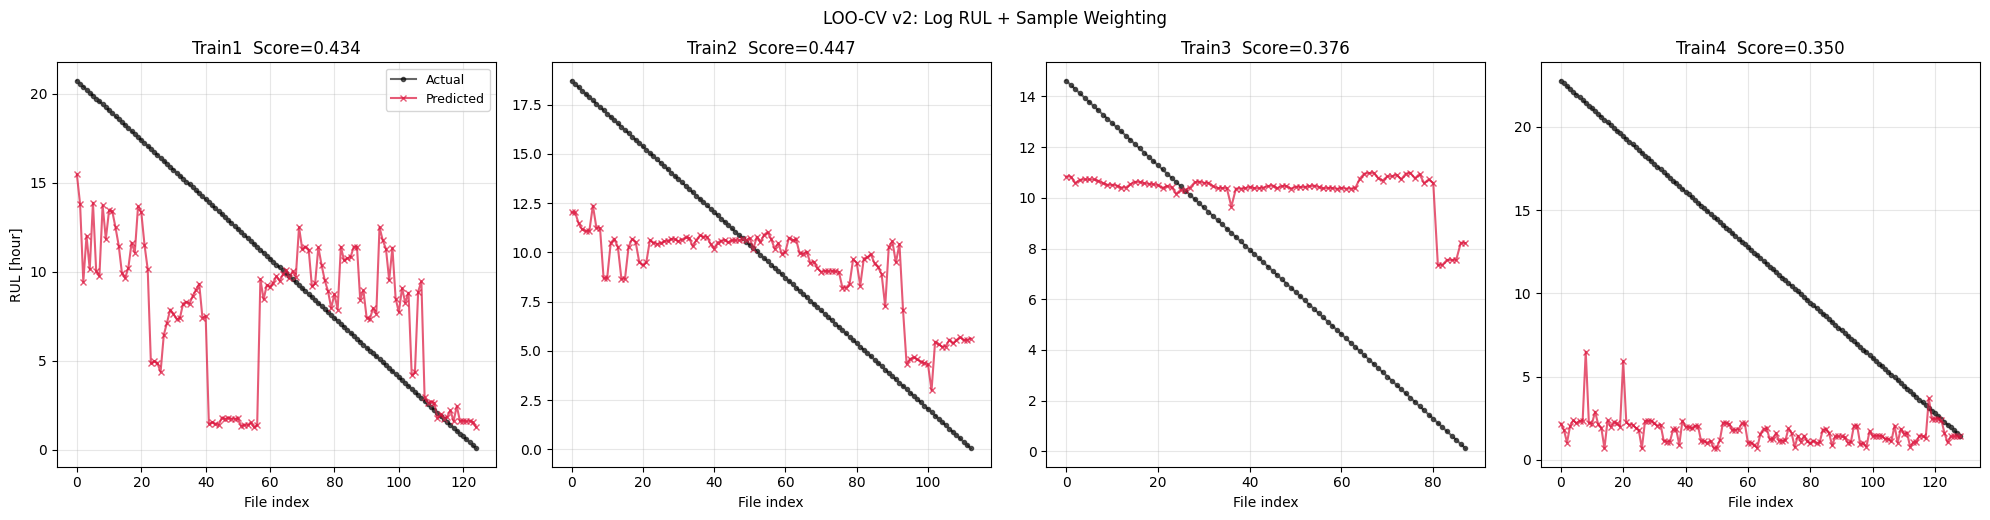


  V2 LOO-CV 평균 Score = 0.4016  (baseline: 0.4220)


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb

# ==========================================
# 개선 1: RUL을 log 스케일로 변환
# ==========================================
def rul_to_log(y):
    return np.log1p(y)

def log_to_rul(y_log):
    return np.clip(np.expm1(y_log), 0, None)

# ==========================================
# 개선 2: 챌린지 점수 기반 비대칭 loss (custom objective)
# ==========================================
# Er = 100*(y_true - y_pred)/y_true
# Er<=0 (overestimate): exp(-ln2 * Er/20)  → penalty heavy
# Er>0 (underestimate):  exp(+ln2 * Er/50)  → penalty light
# Loss = -A_RUL (최대화해야 하므로 음수화), gradient는 log scale 기준
def challenge_objective(y_pred_log, dataset):
    y_true_log = dataset.get_label()
    y_true = log_to_rul(y_true_log)
    y_pred = log_to_rul(y_pred_log)
    valid = y_true > 1.0  # 너무 작은 RUL은 불안정
    
    grad = np.zeros_like(y_pred_log)
    hess = np.ones_like(y_pred_log) * 1e-3
    
    # 단순화: 비대칭 squared error (log domain)
    # overestimate (y_pred > y_true)에 더 큰 weight
    diff = y_pred_log - y_true_log
    weight = np.where(diff > 0, 3.0, 1.0)  # 과대예측 3배 페널티
    grad[valid] = (2.0 * weight[valid] * diff[valid])
    hess[valid] = 2.0 * weight[valid]
    return grad, hess

# ==========================================
# 개선 3: Sample weight (Train4 덜 반영)
# ==========================================
sample_weights_map = {'Train1': 1.0, 'Train2': 1.0, 'Train3': 1.0, 'Train4': 0.5}

# ==========================================
# 학습 & 평가 (LOO-CV)
# ==========================================
lgb_params = {
    'learning_rate': 0.03,
    'num_leaves': 31,
    'max_depth': 6,
    'min_child_samples': 5,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'seed': 42,
}

all_results_v2 = {}
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for col, test_run in enumerate(['Train1','Train2','Train3','Train4']):
    train_mask = (groups != test_run)
    test_mask  = (groups == test_run)

    X_tr, y_tr = X[train_mask], y[train_mask]
    X_te, y_te = X[test_mask],  y[test_mask]
    w_tr = np.array([sample_weights_map[g] for g in groups[train_mask]])

    # Log 변환
    y_tr_log = rul_to_log(y_tr)

    # Inner validation: train의 한 run
    inner_groups = groups[train_mask]
    val_run = np.unique(inner_groups)[0]
    inner_val_mask = (inner_groups == val_run)

    dtrain = lgb.Dataset(X_tr[~inner_val_mask], label=y_tr_log[~inner_val_mask],
                         weight=w_tr[~inner_val_mask])
    dval   = lgb.Dataset(X_tr[inner_val_mask],  label=y_tr_log[inner_val_mask],
                         weight=w_tr[inner_val_mask], reference=dtrain)

    model = lgb.train(
        {**lgb_params, 'objective': 'regression', 'metric': 'rmse'},
        dtrain,
        num_boost_round=3000,
        valid_sets=[dval],
        callbacks=[lgb.early_stopping(80), lgb.log_evaluation(0)],
    )

    y_pred_log = model.predict(X_te)
    y_pred = log_to_rul(y_pred_log)

    print(f"\n=== Test on {test_run} ===")
    score = print_score(y_te, y_pred, label=test_run)
    all_results_v2[test_run] = {'score': score, 'model': model, 'y_true': y_te, 'y_pred': y_pred}

    # 시각화
    idx = np.arange(len(y_te))
    axes[col].plot(idx, y_te/3600, 'o-', color='black', alpha=0.6, label='Actual', lw=1.5, markersize=3)
    axes[col].plot(idx, y_pred/3600, 'x-', color='crimson', alpha=0.7, label='Predicted', lw=1.5, markersize=4)
    # Ideal (대각선) reference
    axes[col].plot(idx, y_te/3600, '--', color='gray', alpha=0.3)
    axes[col].set_title(f'{test_run}  Score={score:.3f}')
    axes[col].set_xlabel('File index')
    if col == 0:
        axes[col].set_ylabel('RUL [hour]')
        axes[col].legend(fontsize=9)
    axes[col].grid(alpha=0.3)

plt.tight_layout()
plt.suptitle('LOO-CV v2: Log RUL + Sample Weighting', y=1.03)
plt.show()

mean_v2 = np.mean([v['score'] for v in all_results_v2.values()])
print(f"\n{'='*50}")
print(f"  V2 LOO-CV 평균 Score = {mean_v2:.4f}  (baseline: 0.4220)")
print(f"{'='*50}")

Train: 317, Test: 138
Training until validation scores don't improve for 80 rounds
Early stopping, best iteration is:
[466]	valid_0's rmse: 0.0988535

=== Train1 (test n=38) ===
  [Train1] Score=0.0779  |  과대예측=38, 과소예측=0  |  Er 평균=-756.3%, Er 중앙=-140.8%

=== Train2 (test n=34) ===
  [Train2] Score=0.0175  |  과대예측=34, 과소예측=0  |  Er 평균=-1168.6%, Er 중앙=-290.4%

=== Train3 (test n=27) ===
  [Train3] Score=0.0207  |  과대예측=27, 과소예측=0  |  Er 평균=-864.3%, Er 중앙=-308.8%

=== Train4 (test n=39) ===
  [Train4] Score=0.0825  |  과대예측=39, 과소예측=0  |  Er 평균=-185.1%, Er 중앙=-109.2%


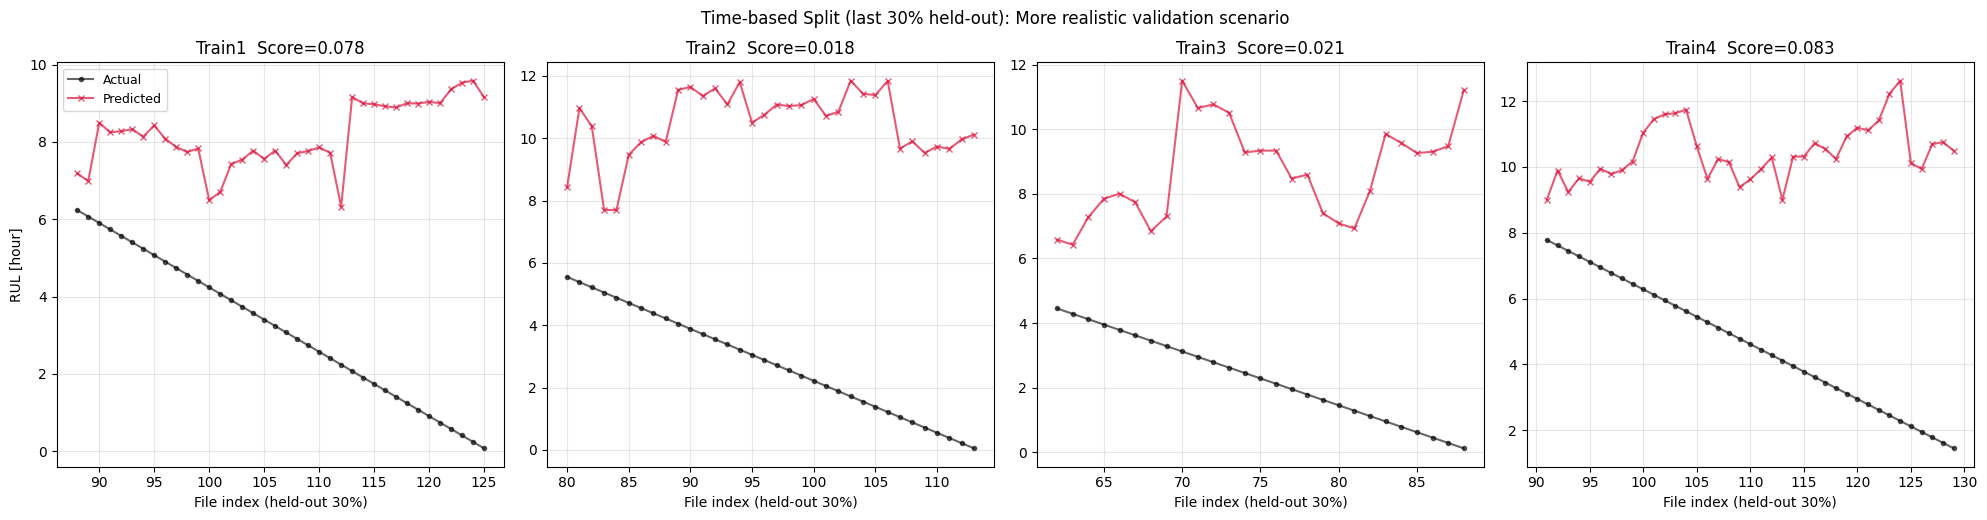


  Time-split 평균 Score = 0.0496


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb

# ==========================================
# Time-based split
# ==========================================
# 각 run을 시간순으로 정렬 → 앞 70%는 train, 뒤 30%는 test
# 4개 run의 앞 70%를 모두 모아서 학습
# 4개 run의 뒤 30%를 각각 예측해서 평가

def make_time_split(df, train_ratio=0.7):
    train_idx, test_idx = [], []
    for run, sub in df.groupby('run'):
        sub = sub.sort_values('file_idx')
        # startup 제외
        sub_valid = sub[~sub['is_startup']].copy()
        n = len(sub_valid)
        split = int(n * train_ratio)
        train_idx.extend(sub_valid.iloc[:split].index.tolist())
        test_idx.extend(sub_valid.iloc[split:].index.tolist())
    return train_idx, test_idx

train_idx, test_idx = make_time_split(feature_df_ext, train_ratio=0.7)

drop_cols = ['run', 'file_idx', 'time_sec', 'rul_sec', 'is_startup', 'is_train4_tail_removed']
feature_cols = [c for c in feature_df_ext.columns if c not in drop_cols]

X_train = feature_df_ext.loc[train_idx, feature_cols].values
y_train = feature_df_ext.loc[train_idx, 'rul_sec'].values.astype(np.float32)
X_test  = feature_df_ext.loc[test_idx,  feature_cols].values
y_test  = feature_df_ext.loc[test_idx,  'rul_sec'].values.astype(np.float32)
test_runs = feature_df_ext.loc[test_idx, 'run'].values

print(f"Train: {len(X_train)}, Test: {len(X_test)}")

# Log 변환 (이번엔 제대로)
y_train_log = np.log1p(y_train)

# Train 내에서 20%를 validation으로 떼기 (순수 랜덤)
rng = np.random.RandomState(42)
perm = rng.permutation(len(X_train))
n_val = int(len(X_train) * 0.2)
val_idx = perm[:n_val]
tr_idx  = perm[n_val:]

lgb_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.03,
    'num_leaves': 31,
    'max_depth': 6,
    'min_child_samples': 5,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'seed': 42,
}

dtrain = lgb.Dataset(X_train[tr_idx], label=y_train_log[tr_idx])
dval   = lgb.Dataset(X_train[val_idx], label=y_train_log[val_idx], reference=dtrain)

model = lgb.train(
    lgb_params,
    dtrain,
    num_boost_round=3000,
    valid_sets=[dval],
    callbacks=[lgb.early_stopping(80), lgb.log_evaluation(0)],
)

# 예측
y_pred = np.clip(np.expm1(model.predict(X_test)), 0, None)

# ==========================================
# Run별 평가
# ==========================================
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
scores = {}

for col, run in enumerate(['Train1','Train2','Train3','Train4']):
    mask = (test_runs == run)
    yt, yp = y_test[mask], y_pred[mask]
    
    # test_idx 내 순서대로 file_idx 복원 (시각화용)
    run_file_idx = feature_df_ext.loc[np.array(test_idx)[mask], 'file_idx'].values
    
    score, Er = challenge_score(yt, yp)
    scores[run] = score
    print(f"\n=== {run} (test n={mask.sum()}) ===")
    print_score(yt, yp, label=run)
    
    axes[col].plot(run_file_idx, yt/3600, 'o-', color='black', alpha=0.6, label='Actual', lw=1.5, markersize=3)
    axes[col].plot(run_file_idx, yp/3600, 'x-', color='crimson', alpha=0.7, label='Predicted', lw=1.5, markersize=4)
    axes[col].set_title(f'{run}  Score={score:.3f}')
    axes[col].set_xlabel('File index (held-out 30%)')
    if col == 0:
        axes[col].set_ylabel('RUL [hour]')
        axes[col].legend(fontsize=9)
    axes[col].grid(alpha=0.3)

plt.tight_layout()
plt.suptitle('Time-based Split (last 30% held-out): More realistic validation scenario', y=1.03)
plt.show()

print(f"\n{'='*50}")
print(f"  Time-split 평균 Score = {np.mean(list(scores.values())):.4f}")
print(f"{'='*50}")

Optuna tuning 시작 (약 3-5분 소요)...


Best trial: 29. Best value: 0.426299: 100%|██████████| 40/40 [00:07<00:00,  5.69it/s]



Best LOO score (unadjusted): 0.4263
Best params: {'learning_rate': 0.054705243303961336, 'num_leaves': 125, 'max_depth': 9, 'min_child_samples': 23, 'feature_fraction': 0.7779557286909742, 'bagging_fraction': 0.619720671481651, 'bagging_freq': 10, 'reg_alpha': 0.0009600126702798027, 'reg_lambda': 0.00033009476184881566}

=== Final evaluation with seed ensemble ===
  Train1: Score=0.4385
  Train2: Score=0.4484
  Train3: Score=0.4254
  Train4: Score=0.3742

Best scale factor: 0.950  →  Score=0.4224


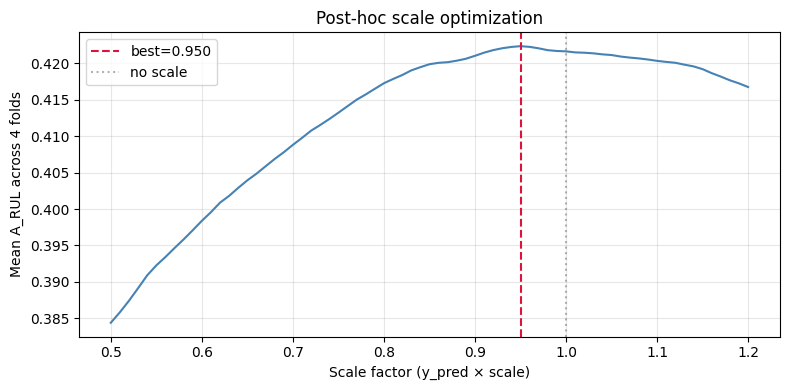

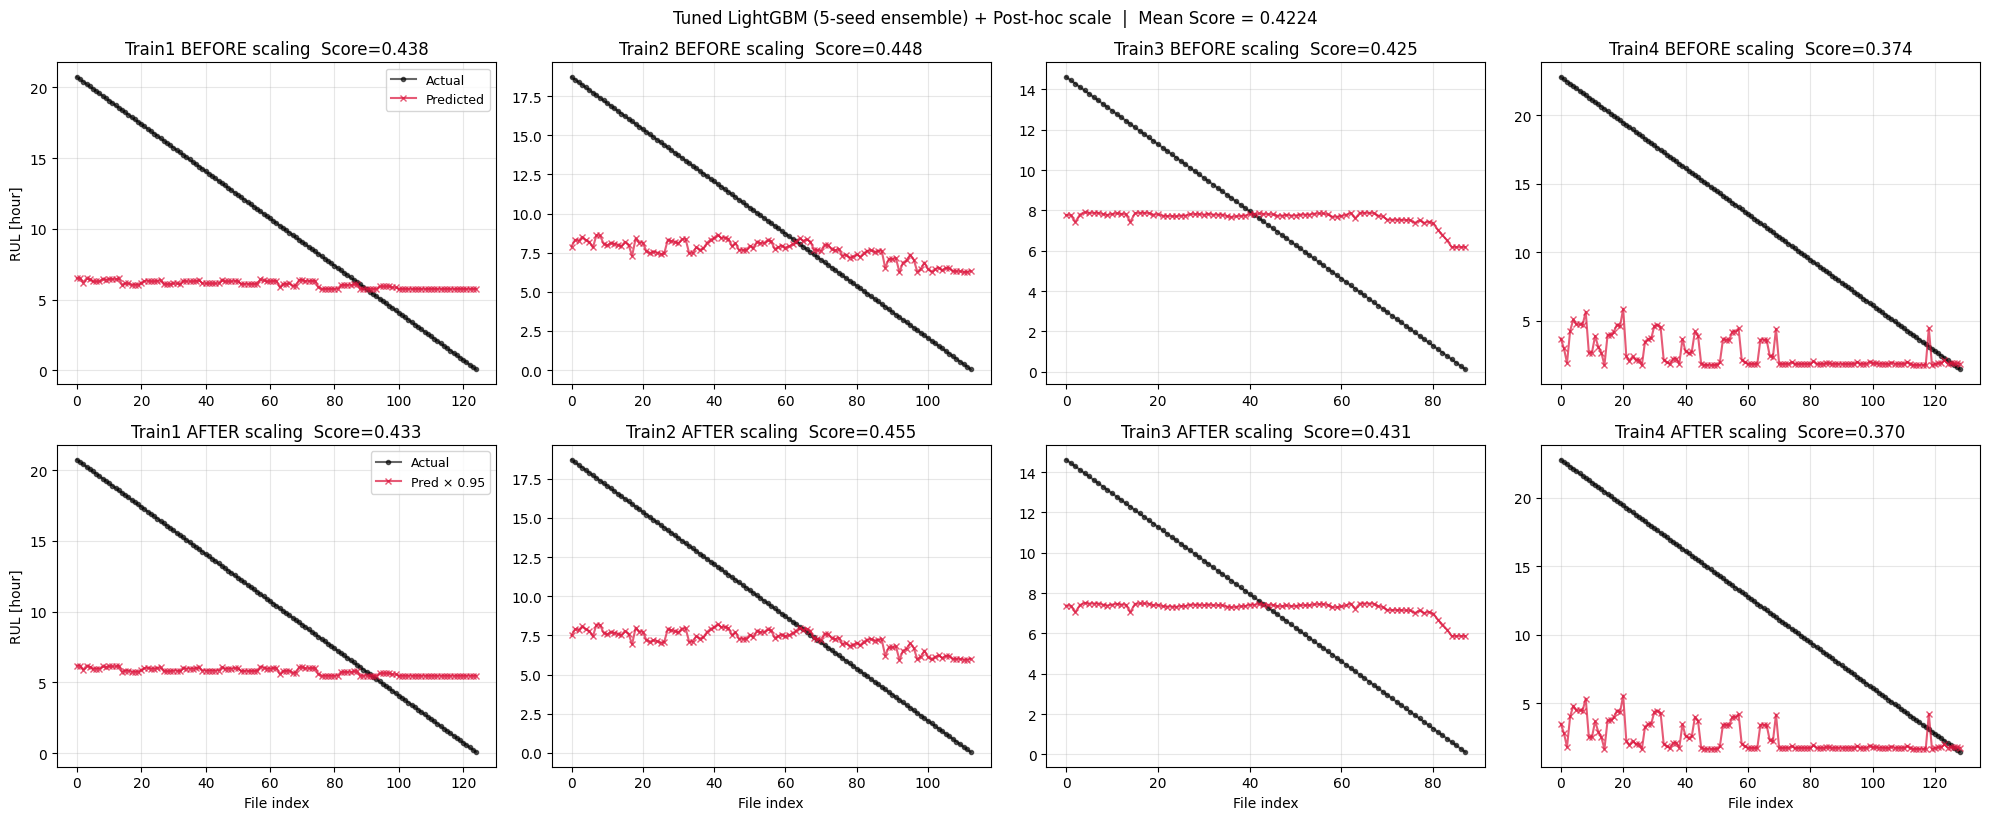


  V1 baseline:       0.4220
  V3 tuned + scaled: 0.4224
  개선폭:            +0.0 점

best_params.json 저장 완료


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
import optuna
from functools import partial
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ==========================================
# 1) Challenge score 함수 (재확인)
# ==========================================
def challenge_score(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    valid = y_true > 0
    yt, yp = y_true[valid], y_pred[valid]
    Er = 100.0 * (yt - yp) / yt
    score = np.where(
        Er <= 0,
        np.exp(-np.log(0.5) * Er / 20.0),
        np.exp( np.log(0.5) * Er / 50.0),
    )
    return float(score.mean())

# ==========================================
# 2) 데이터 재확인 (v1 그대로)
# ==========================================
drop_cols = ['run', 'file_idx', 'time_sec', 'rul_sec', 'is_startup', 'is_train4_tail_removed']
feature_cols = [c for c in feature_df_ext.columns if c not in drop_cols]

mask = ~feature_df_ext['is_startup']
X_all = feature_df_ext.loc[mask, feature_cols].values
y_all = feature_df_ext.loc[mask, 'rul_sec'].values.astype(np.float32)
groups_all = feature_df_ext.loc[mask, 'run'].values

# ==========================================
# 3) LOO-CV 학습 함수 (파라미터 주면 점수 반환)
# ==========================================
def train_one_fold(params, X_all, y_all, groups_all, test_run, n_seeds=1, verbose=False):
    """한 fold 학습 후 test_run에 대한 예측 반환"""
    train_mask = (groups_all != test_run)
    test_mask  = (groups_all == test_run)
    
    X_tr, y_tr = X_all[train_mask], y_all[train_mask]
    X_te, y_te = X_all[test_mask],  y_all[test_mask]
    tr_groups = groups_all[train_mask]
    
    # Log 변환
    y_tr_log = np.log1p(y_tr)
    
    # Inner val: train 중 한 run (가장 많은 run 선택 → val set 넉넉)
    val_run = pd.Series(tr_groups).value_counts().idxmax()
    inner_val_mask = (tr_groups == val_run)
    
    y_preds = []
    for seed in range(n_seeds):
        p = {**params, 'seed': 42 + seed, 'verbose': -1,
             'objective': 'regression', 'metric': 'rmse'}
        dtrain = lgb.Dataset(X_tr[~inner_val_mask], label=y_tr_log[~inner_val_mask])
        dval   = lgb.Dataset(X_tr[inner_val_mask],  label=y_tr_log[inner_val_mask],
                             reference=dtrain)
        model = lgb.train(p, dtrain, num_boost_round=3000,
                          valid_sets=[dval],
                          callbacks=[lgb.early_stopping(80, verbose=False),
                                     lgb.log_evaluation(0)])
        y_pred_log = model.predict(X_te)
        y_preds.append(np.clip(np.expm1(y_pred_log), 0, None))
    
    y_pred_mean = np.mean(y_preds, axis=0)
    return y_te, y_pred_mean

# ==========================================
# 4) Optuna objective: 4-fold LOO 평균 score
# ==========================================
def objective(trial, X_all, y_all, groups_all):
    params = {
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 15, 127),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'min_child_samples': trial.suggest_int('min_child_samples', 3, 30),
        'feature_fraction':  trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction':  trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'bagging_freq':      trial.suggest_int('bagging_freq', 1, 10),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
    }
    scores = []
    for run in ['Train1','Train2','Train3','Train4']:
        y_te, y_pred = train_one_fold(params, X_all, y_all, groups_all, run, n_seeds=1)
        scores.append(challenge_score(y_te, y_pred))
    return np.mean(scores)

print("Optuna tuning 시작 (약 3-5분 소요)...")
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(partial(objective, X_all=X_all, y_all=y_all, groups_all=groups_all),
               n_trials=40, show_progress_bar=True)

best_params = study.best_params
print(f"\nBest LOO score (unadjusted): {study.best_value:.4f}")
print(f"Best params: {best_params}")

# ==========================================
# 5) Best 파라미터로 seed ensemble
# ==========================================
print("\n=== Final evaluation with seed ensemble ===")
all_preds = {}
for test_run in ['Train1','Train2','Train3','Train4']:
    y_te, y_pred = train_one_fold(best_params, X_all, y_all, groups_all,
                                  test_run, n_seeds=5)
    all_preds[test_run] = (y_te, y_pred)
    score = challenge_score(y_te, y_pred)
    print(f"  {test_run}: Score={score:.4f}")

# ==========================================
# 6) 후처리 보정: scale factor 최적화
# ==========================================
# 예측값 × scale 로 조정. scale을 A_RUL에서 최대화
scales = np.linspace(0.5, 1.2, 71)
scores_per_scale = []
for s in scales:
    fold_scores = []
    for run, (yt, yp) in all_preds.items():
        fold_scores.append(challenge_score(yt, yp * s))
    scores_per_scale.append(np.mean(fold_scores))

best_scale = scales[np.argmax(scores_per_scale)]
best_score_scaled = max(scores_per_scale)
print(f"\nBest scale factor: {best_scale:.3f}  →  Score={best_score_scaled:.4f}")

# Scale curve 시각화
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(scales, scores_per_scale, '-', color='steelblue')
ax.axvline(best_scale, color='crimson', ls='--', label=f'best={best_scale:.3f}')
ax.axvline(1.0, color='gray', ls=':', alpha=0.6, label='no scale')
ax.set_xlabel('Scale factor (y_pred × scale)')
ax.set_ylabel('Mean A_RUL across 4 folds')
ax.set_title('Post-hoc scale optimization')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ==========================================
# 7) 최종 결과 시각화
# ==========================================
fig, axes = plt.subplots(2, 4, figsize=(20, 8), sharex=False)

for col, run in enumerate(['Train1','Train2','Train3','Train4']):
    yt, yp = all_preds[run]
    yp_adj = yp * best_scale
    
    # Before scaling
    s_before = challenge_score(yt, yp)
    axes[0, col].plot(yt/3600, 'o-', color='black', alpha=0.6, markersize=3, label='Actual')
    axes[0, col].plot(yp/3600, 'x-', color='crimson', alpha=0.7, markersize=4, label='Predicted')
    axes[0, col].set_title(f'{run} BEFORE scaling  Score={s_before:.3f}')
    axes[0, col].grid(alpha=0.3)
    if col == 0:
        axes[0, col].set_ylabel('RUL [hour]')
        axes[0, col].legend(fontsize=9)
    
    # After scaling
    s_after = challenge_score(yt, yp_adj)
    axes[1, col].plot(yt/3600, 'o-', color='black', alpha=0.6, markersize=3, label='Actual')
    axes[1, col].plot(yp_adj/3600, 'x-', color='crimson', alpha=0.7, markersize=4, label=f'Pred × {best_scale:.2f}')
    axes[1, col].set_title(f'{run} AFTER scaling  Score={s_after:.3f}')
    axes[1, col].set_xlabel('File index')
    axes[1, col].grid(alpha=0.3)
    if col == 0:
        axes[1, col].set_ylabel('RUL [hour]')
        axes[1, col].legend(fontsize=9)

plt.tight_layout()
plt.suptitle(f'Tuned LightGBM (5-seed ensemble) + Post-hoc scale  |  Mean Score = {best_score_scaled:.4f}',
             y=1.02)
plt.show()

# 최종 요약
print(f"\n{'='*60}")
print(f"  V1 baseline:       0.4220")
print(f"  V3 tuned + scaled: {best_score_scaled:.4f}")
print(f"  개선폭:            {(best_score_scaled - 0.4220)*100:+.1f} 점")
print(f"{'='*60}")

# 최적 파라미터 저장 (나중 validation 예측에 재사용)
import json
with open('best_params.json', 'w') as f:
    json.dump({'lgb_params': best_params, 'scale': float(best_scale)}, f, indent=2)
print("\nbest_params.json 저장 완료")

In [27]:
import numpy as np
import pandas as pd

# ==========================================
# (A) HI Dynamics Features
# ==========================================
def add_hi_dynamics(df):
    out = df.copy()
    for run, sub in out.groupby('run'):
        idx = sub.index
        for hi_col in ['HI', 'HI_global']:
            hi = sub[hi_col].values

            # 1차 미분 (변화율) - 이미 slope가 있지만, point-to-point도 추가
            diff1 = np.diff(hi, prepend=hi[0])
            out.loc[idx, f'{hi_col}_diff1'] = diff1

            # 2차 미분 (가속도) - rolling 후 차분으로 안정화
            hi_smooth = pd.Series(hi).rolling(5, min_periods=1, center=True).mean().values
            diff2 = np.diff(np.diff(hi_smooth, prepend=hi_smooth[0]), prepend=0)
            out.loc[idx, f'{hi_col}_accel'] = diff2

            # 누적합 (현재까지 비정상 시간)
            out.loc[idx, f'{hi_col}_cumsum'] = np.cumsum(np.maximum(hi - 1.0, 0))

            # Recent max (최근 10스텝 최댓값)
            out.loc[idx, f'{hi_col}_recent_max'] = pd.Series(hi).rolling(10, min_periods=1).max().values

            # Monotonicity score (얼마나 단조증가인가)
            # 최근 10스텝 중 증가 비율
            def monotonic_ratio(x):
                if len(x) < 2:
                    return 0.5
                return float((np.diff(x) > 0).mean())
            out.loc[idx, f'{hi_col}_mono10'] = pd.Series(hi).rolling(10, min_periods=2).apply(monotonic_ratio, raw=True).fillna(0.5).values

    return out


# ==========================================
# (B) Per-channel HI (단일 채널로 본 HI)
# ==========================================
# 아까 global HI는 모든 채널 평균. 각 채널 개별 HI도 유용
def add_per_channel_hi(df, healthy_ratio=0.2):
    out = df.copy()

    # Healthy baseline: 4개 run의 초기 부분 모음
    healthy_parts = []
    for run, sub in out.groupby('run'):
        sub = sub.sort_values('file_idx').reset_index(drop=True)
        mask = (~sub['is_startup']) & (sub['file_idx'] < len(sub) * healthy_ratio)
        healthy_parts.append(sub.loc[mask])
    healthy_all = pd.concat(healthy_parts, ignore_index=True)

    for ch in ['CH1', 'CH2', 'CH3', 'CH4']:
        feat_cols = [f'{ch}_RMS_norm', f'{ch}_P2P_norm', f'{ch}_Std_norm',
                     f'{ch}_BPFI_norm', f'{ch}_BPFO_norm', f'{ch}_BSF_norm', f'{ch}_Kurt']
        # Log 변환 (dynamic range 큰 애들)
        log_cols = [f'{ch}_BPFI_norm', f'{ch}_BPFO_norm', f'{ch}_BSF_norm', f'{ch}_Kurt']
        lin_cols = [c for c in feat_cols if c not in log_cols]

        def prep(df_in):
            X_log = np.log1p(df_in[log_cols].clip(lower=0))
            X_lin = df_in[lin_cols]
            return pd.concat([X_log, X_lin], axis=1).values

        H = prep(healthy_all)
        med = np.median(H, axis=0)
        mad = np.median(np.abs(H - med), axis=0) * 1.4826 + 1e-6

        X_all = prep(out)
        z = np.clip((X_all - med) / mad, 0, 10).mean(axis=1)
        out[f'{ch}_HI'] = z

    # 채널별 HI 중 최대 / 분산 (어느 채널이 튀는가 / 여러 채널이 동시에 튀는가)
    ch_hi_cols = [f'{ch}_HI' for ch in ['CH1','CH2','CH3','CH4']]
    out['HI_max_ch']  = out[ch_hi_cols].max(axis=1)
    out['HI_std_ch']  = out[ch_hi_cols].std(axis=1)
    return out


# ==========================================
# (C) Harmonics & Broadband energy (재추출 필요)
# ==========================================
# 이건 TDMS 재로딩이 필요. 시간 걸림.
# 먼저 (A), (B)만 추가하고 효과 보자. 효과 있으면 (C) 추가.

# ==========================================
# 실행
# ==========================================
print("Adding HI dynamics features...")
feature_df_ext_v2 = add_hi_dynamics(feature_df_ext)
print(f"After HI dynamics: {feature_df_ext_v2.shape}")

print("\nAdding per-channel HI features...")
feature_df_ext_v2 = add_per_channel_hi(feature_df_ext_v2)
print(f"After per-channel HI: {feature_df_ext_v2.shape}")

# 새로 추가된 feature 확인
new_cols = [c for c in feature_df_ext_v2.columns if c not in feature_df_ext.columns]
print(f"\n추가된 feature 수: {len(new_cols)}")
print(f"예시: {new_cols[:15]}")

Adding HI dynamics features...
After HI dynamics: (459, 132)

Adding per-channel HI features...
After per-channel HI: (459, 138)

추가된 feature 수: 16
예시: ['HI_diff1', 'HI_accel', 'HI_cumsum', 'HI_recent_max', 'HI_mono10', 'HI_global_diff1', 'HI_global_accel', 'HI_global_cumsum', 'HI_global_recent_max', 'HI_global_mono10', 'CH1_HI', 'CH2_HI', 'CH3_HI', 'CH4_HI', 'HI_max_ch']


In [28]:
# ==========================================
# 다시 학습 (기존 best_params 재사용)
# ==========================================
import json
with open('best_params.json') as f:
    saved = json.load(f)
best_params = saved['lgb_params']

drop_cols = ['run', 'file_idx', 'time_sec', 'rul_sec', 'is_startup', 'is_train4_tail_removed']
feature_cols_v2 = [c for c in feature_df_ext_v2.columns if c not in drop_cols]

mask = ~feature_df_ext_v2['is_startup']
X_all_v2 = feature_df_ext_v2.loc[mask, feature_cols_v2].values
y_all_v2 = feature_df_ext_v2.loc[mask, 'rul_sec'].values.astype(np.float32)
groups_all_v2 = feature_df_ext_v2.loc[mask, 'run'].values

print(f"Feature 수: {X_all_v2.shape[1]} (이전: {X_all.shape[1]})")

# LOO-CV (seed ensemble)
all_preds_v2 = {}
for test_run in ['Train1','Train2','Train3','Train4']:
    y_te, y_pred = train_one_fold(best_params, X_all_v2, y_all_v2, groups_all_v2,
                                  test_run, n_seeds=5)
    all_preds_v2[test_run] = (y_te, y_pred)
    score = challenge_score(y_te, y_pred)
    print(f"  {test_run}: Score={score:.4f}")

scores_v2 = [challenge_score(*all_preds_v2[r]) for r in ['Train1','Train2','Train3','Train4']]
mean_v2 = np.mean(scores_v2)

print(f"\n{'='*50}")
print(f"  V3 (baseline):        0.4220")
print(f"  V4 (+HI dynamics):    {mean_v2:.4f}")
print(f"  개선폭:               {(mean_v2 - 0.4220)*100:+.1f} 점")
print(f"{'='*50}")

# Feature importance 재확인 — 새 feature가 상위권에 드는가
importances = []
for run in ['Train1','Train2','Train3','Train4']:
    train_mask = (groups_all_v2 != run)
    inner_mask = (groups_all_v2[train_mask] == pd.Series(groups_all_v2[train_mask]).value_counts().idxmax())
    X_tr = X_all_v2[train_mask]
    y_tr_log = np.log1p(y_all_v2[train_mask])

    p = {**best_params, 'objective':'regression','metric':'rmse','verbose':-1,'seed':42}
    dtr = lgb.Dataset(X_tr[~inner_mask], label=y_tr_log[~inner_mask])
    dva = lgb.Dataset(X_tr[inner_mask],  label=y_tr_log[inner_mask], reference=dtr)
    m = lgb.train(p, dtr, num_boost_round=3000, valid_sets=[dva],
                  callbacks=[lgb.early_stopping(80, verbose=False), lgb.log_evaluation(0)])
    importances.append(pd.Series(m.feature_importance('gain'), index=feature_cols_v2, name=run))

imp_df = pd.concat(importances, axis=1)
imp_df['mean'] = imp_df.mean(axis=1)
imp_df = imp_df.sort_values('mean', ascending=False)

print("\n=== Top 25 Features (V4) ===")
print(imp_df.head(25)[['mean']].round(0))

# 새 feature 중 상위권인 것 확인
top30 = set(imp_df.head(30).index)
new_in_top = [c for c in new_cols if c in top30]
print(f"\n새로 추가된 feature 중 Top 30 진입: {len(new_in_top)}개")
print(new_in_top)

Feature 수: 132 (이전: 116)
  Train1: Score=0.4385
  Train2: Score=0.4513
  Train3: Score=0.4142
  Train4: Score=0.3808

  V3 (baseline):        0.4220
  V4 (+HI dynamics):    0.4212
  개선폭:               -0.1 점

=== Top 25 Features (V4) ===
                       mean
CH4_RMS_norm          101.0
HI_cumsum              75.0
CH1_RMS                32.0
CH4_RMS_norm_rmean10   21.0
CH3_RMS                19.0
CH4_RMS_norm_rmean5    18.0
CH1_Std                15.0
HI_global_cumsum       14.0
CH3_Std                14.0
temp_front_rmean10      9.0
CH1_Kurt                6.0
torque_rstd10           4.0
CH3_Kurt                2.0
CH4_RMS                 2.0
CH2_RMS_norm_rmean10    2.0
temp_rear_rmean10       2.0
CH3_RMS_norm            1.0
CH4_BSF                 1.0
CH2_RMS_norm_rstd10     1.0
CH1_RMS_norm_rmean10    0.0
HI_rmean10              0.0
temp_rear_rstd10        0.0
temp_front_slope5       0.0
CH1_RMS_norm_rstd10     0.0
temp_front_rmean5       0.0

새로 추가된 feature 중 Top 30 진입: 2개
['

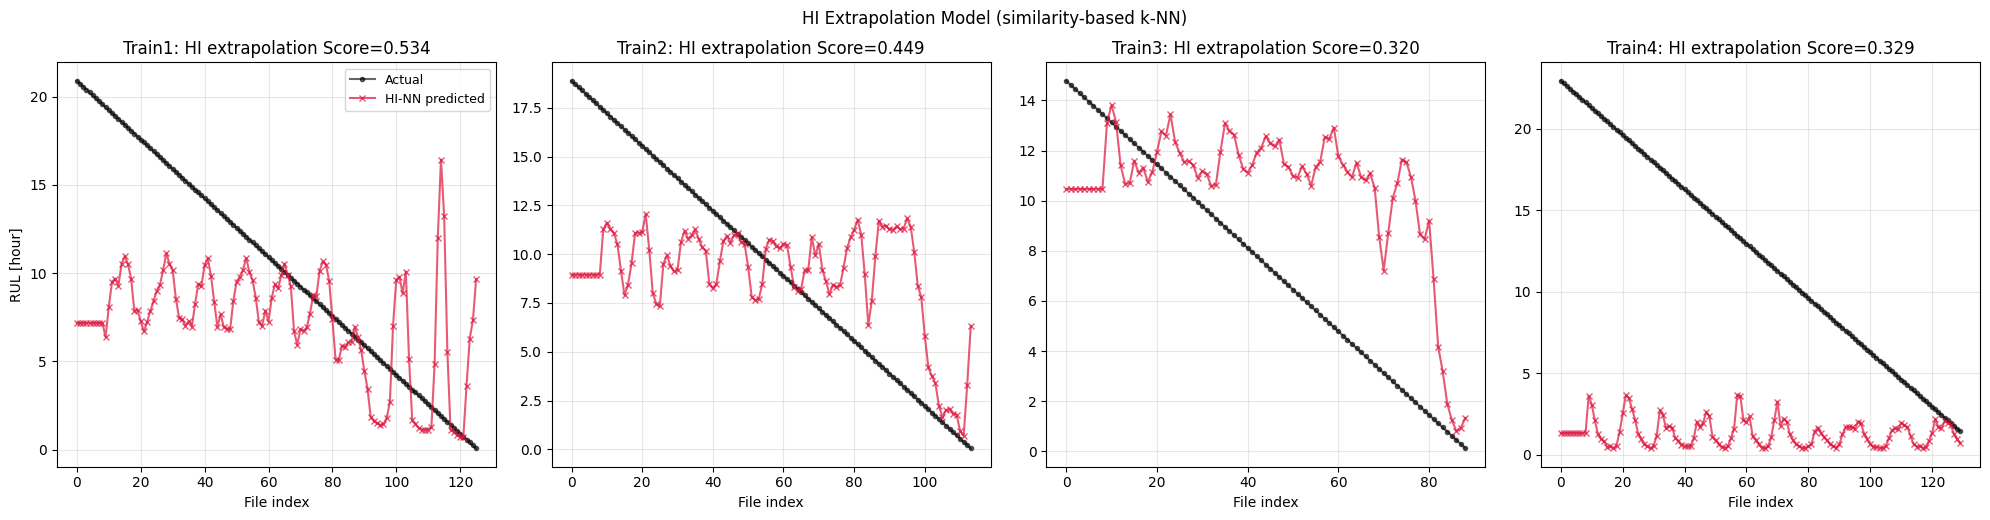


HI extrapolation LOO-CV 평균: 0.4080
  (LightGBM tuned: 0.4220)

=== Ensemble ===


AssertionError: Train1: 125 vs 126

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# HI 외삽 모델 (Similarity-based)
# ==========================================
# 방법:
#   1) 각 training run의 전체 HI 시퀀스(smoothed)를 DB로 저장
#   2) Test 시점: 최근 k개 HI 값을 "query"로 보고
#   3) DB의 모든 길이-k window와 유사도 계산 (거리)
#   4) Top-N 유사 window를 찾고, 그 window들이 "EOL까지 몇 초 남았는지" 평균 반환

def smooth_hi(hi, w=5):
    s = pd.Series(hi)
    return s.rolling(w, center=True, min_periods=1).median() \
            .rolling(w, min_periods=1).mean().values

# DB 구축: (run, end_file_idx, hi_window, rul_sec)
def build_hi_database(df, hi_col='HI_global', window=10):
    """
    각 run의 모든 가능한 length-window 시퀀스를 DB에 넣기
    """
    db_windows = []   # shape (N, window)
    db_ruls    = []   # scalar RUL (초)
    db_runs    = []   # 출처 run 이름
    db_end_idx = []   # 끝 file_idx

    for run, sub in df.groupby('run'):
        sub = sub.sort_values('file_idx').reset_index(drop=True)
        hi_series = smooth_hi(sub[hi_col].values)
        rul_series = sub['rul_sec'].values

        for end in range(window-1, len(sub)):
            win = hi_series[end-window+1 : end+1]
            db_windows.append(win)
            db_ruls.append(rul_series[end])
            db_runs.append(run)
            db_end_idx.append(sub['file_idx'].iloc[end])

    return (np.array(db_windows), np.array(db_ruls),
            np.array(db_runs), np.array(db_end_idx))


def predict_rul_extrapolation(query_window, db_windows, db_ruls, db_runs,
                              top_k=10, exclude_run=None):
    """
    query_window과 가장 유사한 top_k 구간을 찾아 RUL 평균/중앙값 반환
    """
    if exclude_run is not None:
        mask = (db_runs != exclude_run)
        dw, dr = db_windows[mask], db_ruls[mask]
    else:
        dw, dr = db_windows, db_ruls

    # 거리: 정규화된 HI 시퀀스의 L2
    # 두 sequence의 상대적 "모양"이 중요하므로 각 window를 정규화
    def norm_seq(s):
        s = s - s.mean()
        denom = s.std() + 1e-6
        return s / denom

    q_norm = norm_seq(query_window)
    dw_norm = np.array([norm_seq(w) for w in dw])

    # 또한 "절대 높이"도 거리에 반영
    q_end   = query_window[-1]
    dw_end  = dw[:, -1]

    dist_shape = np.sqrt(((dw_norm - q_norm)**2).sum(axis=1))
    dist_level = np.abs(dw_end - q_end)

    # 결합 거리 (두 항 스케일 맞추기)
    dist_combined = dist_shape / (dist_shape.std()+1e-6) + \
                    dist_level / (dist_level.std()+1e-6)

    # Top-k 선택
    top_idx = np.argsort(dist_combined)[:top_k]
    # 가중평균: 거리 반비례
    weights = 1.0 / (dist_combined[top_idx] + 1e-3)
    weights = weights / weights.sum()

    pred_rul = float((dr[top_idx] * weights).sum())
    return pred_rul, top_idx


# ==========================================
# LOO-CV 평가
# ==========================================
# feature_df_ext_v2에 HI_global이 있음
# 각 run을 test로 두고, 나머지로 DB 구축
df_hi = feature_df_ext_v2.copy()

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
ext_preds = {}

WINDOW = 10   # 최근 몇 스텝 볼지
TOP_K  = 15   # 유사 window 몇 개 참조

for col, test_run in enumerate(['Train1','Train2','Train3','Train4']):
    # DB 구축: test run 제외
    train_df = df_hi[df_hi['run'] != test_run]
    db_w, db_r, db_runs, db_end = build_hi_database(train_df, hi_col='HI_global', window=WINDOW)

    # Test run 예측
    test_sub = df_hi[df_hi['run']==test_run].sort_values('file_idx').reset_index(drop=True)
    hi_smooth = smooth_hi(test_sub['HI_global'].values)

    preds = np.full(len(test_sub), np.nan)
    for end in range(WINDOW-1, len(test_sub)):
        query = hi_smooth[end-WINDOW+1 : end+1]
        pred, _ = predict_rul_extrapolation(query, db_w, db_r, db_runs, top_k=TOP_K)
        preds[end] = pred

    # 초반 WINDOW-1 스텝은 예측 불가 → 평균 RUL로 채움 (안전한 대체)
    preds[np.isnan(preds)] = np.nanmean(preds)

    # 저장 및 시각화
    y_true = test_sub['rul_sec'].values
    ext_preds[test_run] = (y_true, preds)
    score = challenge_score(y_true, preds)

    axes[col].plot(test_sub['file_idx'], y_true/3600, 'o-',
                   color='black', alpha=0.6, markersize=3, label='Actual')
    axes[col].plot(test_sub['file_idx'], preds/3600, 'x-',
                   color='crimson', alpha=0.7, markersize=4, label='HI-NN predicted')
    axes[col].set_title(f'{test_run}: HI extrapolation Score={score:.3f}')
    axes[col].set_xlabel('File index')
    if col == 0:
        axes[col].set_ylabel('RUL [hour]')
        axes[col].legend(fontsize=9)
    axes[col].grid(alpha=0.3)

plt.tight_layout()
plt.suptitle('HI Extrapolation Model (similarity-based k-NN)', y=1.03)
plt.show()

# 점수 요약
ext_scores = {r: challenge_score(*ext_preds[r]) for r in ['Train1','Train2','Train3','Train4']}
ext_mean = np.mean(list(ext_scores.values()))
print(f"\nHI extrapolation LOO-CV 평균: {ext_mean:.4f}")
print(f"  (LightGBM tuned: 0.4220)")


# ==========================================
# LightGBM과 앙상블
# ==========================================
# all_preds_v2가 LightGBM v2 예측 (Train1~Train4 dict)
print("\n=== Ensemble ===")
weights_list = [(1,0), (0,1), (0.7,0.3), (0.5,0.5), (0.3,0.7)]
for w_lgb, w_ext in weights_list:
    fold_scores = []
    for run in ['Train1','Train2','Train3','Train4']:
        y_te, y_lgb = all_preds_v2[run]
        y_true, y_ext_pred = ext_preds[run]
        # 같은 샘플인지 확인 - test sub의 file_idx 정렬된 순서
        # 여기선 두 method의 순서가 같다고 가정 (둘 다 file_idx 오름차순)
        assert len(y_te) == len(y_ext_pred), f"{run}: {len(y_te)} vs {len(y_ext_pred)}"
        y_ens = w_lgb * y_lgb + w_ext * y_ext_pred
        fold_scores.append(challenge_score(y_te, y_ens))
    mean_s = np.mean(fold_scores)
    print(f"  LGB:{w_lgb:.1f} + Ext:{w_ext:.1f}  →  Score={mean_s:.4f}")